# EDA de videos crudos - `data/raw`

**Proyecto:** deteccion y conteo automatico de gallinas ponedoras (Granja rural, Lima - Peru)
**Notebook:** `11_EDA_videos.ipynb`
**Fuente de datos:** `data/raw/*.mp4` (10 grabaciones, 1920x1080, h264, ~15 fps)

Este notebook realiza un **Analisis Exploratorio de Datos (EDA)** sobre las grabaciones originales,
antes de cualquier particionamiento en fotogramas. El objetivo es responder tres preguntas:

1. **Que material tengo?** -> inventario, duracion, resolucion, codec, almacenamiento.
2. **Que calidad tiene?** -> iluminacion, exposicion, contraste, nitidez, color, ruido, compresion.
3. **Que me sirve para detectar gallinas?** -> movimiento, estabilidad de camara, continuidad,
   cambios de escena y redundancia entre fotogramas.

Todas las metricas se calculan **sin decodificar los videos completos**: se usa *seek* directo a
los fotogramas de interes, por lo que el analisis completo tarda pocos minutos. Los resultados se
guardan como cache en `artifacts/eda_videos/` y se reutilizan en ejecuciones posteriores.

## Mapa de categorias metricas

| Categoria | Variables extraidas | Para que sirven |
|---|---|---|
| Informacion del archivo | nombre, tamano MB, formato, codec, bitrate | Inventariar videos, almacenamiento y compatibilidad |
| Duracion y fotogramas | duracion (s / min), numero de fotogramas, FPS, consistencia FPS | Comparar extension y resolucion temporal de las grabaciones |
| Resolucion | ancho, alto, megapixeles, relacion de aspecto, orientacion | Identificar diferencias de tamano y encuadre |
| Compresion | bitrate (kbps), bits por pixel, `blockiness` (bordes de macrobloque 8x8) | Detectar perdida de detalle que dificulta la deteccion de objetos |
| Brillo | media, mediana, desviacion, percentiles P05-P95, IQR | Identificar escenas oscuras/claras y cambios de iluminacion |
| Exposicion | indice de exposicion, % pixeles oscuros, % claros, % quemados | Detectar zonas subexpuestas o sobreexpuestas |
| Contraste | desviacion de intensidades, rango dinamico, Michelson, entropia | Evaluar cuanto se distinguen los objetos del fondo |
| Nitidez y desenfoque | varianza del Laplaciano, Tenengrad, bordes debiles, densidad de bordes, nitidez relativa | Encontrar fotogramas borrosos (comparacion dentro de cada video) |
| Color | medias y desviaciones RGB, saturacion, valor, tono circular, entropia de tono, colorfulness, balance de blancos | Detectar cambios de color, iluminacion o apariencia entre grabaciones |
| Ruido visual | sigma de Immerkaer (`ruido`), ruido en zonas planas (`ruido_plano`) | Identificar imagenes con granulado o interferencias |
| Movimiento | diferencia media entre fotogramas, P95, % pixeles cambiados, magnitud de flujo optico | Medir actividad y localizar periodos con poco o mucho movimiento |
| Estabilidad de camara | traslacion global, rotacion, escala, coherencia del flujo, sacudida, inliers RANSAC | Distinguir movimiento de camara del movimiento de los objetos |
| Continuidad | fotogramas negros, congelamientos, duplicados exactos (dHash), saltos de timestamp | Detectar problemas de grabacion |
| Cambios de escena | distancia de histogramas, cortes detectados | Dividir el video en segmentos visualmente diferentes |
| Similitud entre fotogramas | correlacion de histogramas, dHash, seleccion diversa | Detectar redundancia y elegir fotogramas variados para etiquetar |

### Estadisticas adicionales (propuestas)

Ademas de la tabla anterior, este notebook calcula utiles que no estaban en la lista original:

- **`densidad_bordes`** (Canny) y **`bordes_debiles`** (P95 de |Sobel|): complementan la nitidez y
  ayudan a separar "borroso por movimiento" de "escena sin textura".
- **`entropia`** de la imagen y **`entropia_tono`**: cuantifican la complejidad de la escena y la
  variedad de colores; son utiles para elegir los fotogramas mas informativos.
- **`colorfulness`** (Hasler & Susstrunk) y **`balance_blancos`**: detectan cambios de iluminacion
  artificial y variaciones de temperatura de color entre dias y camaras.
- **`rango_dinamico`** y **`contraste_michelson`**: metricas normalizadas que no dependen de la
  resolucion, por lo que son comparables entre grabaciones.
- **`flujo_coherencia`** = |flujo medio| / |flujo| medio: separa movimiento global de camara
  (coherente) de movimiento local de las gallinas (incoherente). Es clave para el modelo.
- **`camara_inliers`**, **`camara_escala`** y **`rotacion_std`**: detectan vibracion, reencuadre o
  zoom accidental.
- **`blockiness`**: indice clasico de bloqueado 8x8, proxy directo de la compresion del video.
- **`nitidez_relativa`**: nitidez normalizada dentro de cada video; permite detectar fotogramas
  borrosos aunque el video completo sea de baja nitidez.
- **`brillo_relativo`**, **`contraste_relativo`**, **`es_brillo_anomalo`**, **`es_contraste_bajo`**:
  flags *relativos* a la mediana del propio video. Son los que de verdad detectan fotogramas
  atipicos, porque un umbral absoluto (por ejemplo "> 35% de pixeles oscuros") marca el 100% o el 0%
  del dataset segun la iluminacion de la granja.
- **`racha_identicos`** y **`es_stall`**: en una escena estatica a 15 fps el 54% de los fotogramas
  consecutivos son perceptualmente identicos. No es un problema; un problema es una racha larga.
- **`z_robusto_hist`** y **`corte_escena_adaptivo`**: cortes de escena con criterio estadistico
  (mediana + K * desviacion robusta) en vez de un umbral fijo.
- **`nivel_luz`**, **`nivel_movimiento`**, **`pct_negros`**, **`pct_congelados`**, **`pct_duplicados`**,
  **`n_cortes`**: variables de salud de la grabacion, utiles como filtro de calidad del dataset.
- **`calidad_global`** (score 0-100 ponderado) y **seleccion diversa** (farthest-point sampling)
  para construir el conjunto de etiquetado.
- **Relacion luz vs. hora del dia**, extraida del nombre del archivo, para caracterizar el ciclo de
  iluminacion de la granja y anticipar sesgos de generalizacion.

## 1. Configuracion

In [1]:
import os
os.chdir(r"B:\11RossyDocumentos\18ProyectoPollos\12Avances\11_proyecto_pollos")

import re
import math
import time
import json
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 230)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

plt.rcParams.update({
    "figure.max_open_warning": 0,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})

In [2]:
try:
    from siuba import *          # verbs: filter, mutate, summarize, groupby ...
    print("siuba disponible")
except Exception as exc:         # pragma: no cover
    print("siuba no disponible:", exc)

print("opencv", cv2.__version__)
print("numpy ", np.__version__)
print("pandas", pd.__version__)
print("matplotlib", plt.matplotlib.__version__)

siuba disponible
opencv 5.0.0
numpy  2.3.5
pandas 2.3.3
matplotlib 3.11.2


### Parametros del analisis

Ajuste estas variables para cambiar la profundidad del analisis:

- `MUESTREO_SEGUNDOS`: cada cuantos segundos se analiza un fotograma. **Menor valor = mas detalle y
  mas tiempo**. Un muestreo de 5 s analiza ~250 fotogramas por video; 2 s analiza ~625.
- `ANALIZAR_DENSIDAD`, `N_VENTANAS_DENSAS`, `SEGUNDOS_DENSOS`: barrido a FPS nativo sobre ventanas
  cortas. Es la unica forma fiable de detectar congelamientos de 1-3 s, que el muestreo puede saltar.
- `ANALIZAR_MOVIMIENTO`: activa el flujo optico y la estimacion de estabilidad de camara. Es la
  parte mas costosa (aprox. 2 de cada 3 operaciones del analisis).
- `LIMITE_VIDEOS` / `MAX_FRAMES_VIDEO`: utiles para hacer pruebas rapidas antes de la corrida completa.

In [3]:
RAIZ = Path.cwd()
DIR_VIDEOS = RAIZ / "data" / "raw"
DIR_OUT = RAIZ / "artifacts" / "eda_videos"
DIR_OUT.mkdir(parents=True, exist_ok=True)

EXTENSIONES = {".mp4", ".avi", ".mov", ".mkv", ".m4v", ".wmv", ".flv", ".webm"}

# --- muestreo ---
MUESTREO_SEGUNDOS = 5.0      # 5 s -> ~250 fotogramas/video ; 2 s -> ~625 (mas lento)
LIMITE_VIDEOS = None         # None = todos ; ej. 2 para una prueba rapida
MAX_FRAMES_VIDEO = None      # None = sin tope (solo depuracion)

# --- barrido denso a FPS nativo (continuidad) ---
ANALIZAR_DENSIDAD = True
N_VENTANAS_DENSAS = 2        # ventanas por video
SEGUNDOS_DENSOS = 30         # duracion de cada ventana

# --- rendimiento ---
ANALIZAR_MOVIMIENTO = True   # flujo optico + estabilidad de camara
ANCHO_FLUJO = 320            # resolucion de trabajo para flujo optico
ANCHO_CALIDAD = 960          # resolucion de trabajo para color y bordes

# --- umbrales absolutos ---
UMBRAL_NEGRO_BRILLO = 12.0     # brillo medio < 12       -> fotograma negro
UMBRAL_CONGELADO_DIFF = 0.55   # |dif| media < 0.55      -> imagen congelada
UMBRAL_ESCUROS_PCT = 5.0       # % pixeles < 16  > 5     -> subexpuesto
UMBRAL_QUEMADOS_PCT = 5.0      # % pixeles >= 250 > 5    -> sobreexpuesto
UMBRAL_CLAROS_PCT = 10.0       # % pixeles > 240 > 10    -> sobreexpuesto
UMBRAL_DUPLICADO_HAMMING = 4   # dHash hamming <= 4      -> fotograma repetido
UMBRAL_RACHA_STALL = 15        # 15 fotogramas identicos -> grabacion detenida

# --- umbrales relativos (calculados dentro de cada video) ---
UMBRAL_BORROSO_REL = 0.40      # nitidez relativa < 0.40        -> borroso
UMBRAL_BRILLO_REL = 0.15       # |desv. brillo rel.| > 15%      -> brillo anomalo
UMBRAL_CONTRASTE_REL = 0.70    # contraste < 0.70 x su mediana  -> contraste bajo

# --- criterio de corte de escena ---
UMBRAL_CORTE_ESCENA = 0.10     # 1 - correlacion(hist) > 0.10 -> corte de escena
K_MAD_CORTE = 6.0              # corte adaptativo: mediana + K_MAD * sigma robusta

# --- pesos del score de calidad global (0-100) ---
PESOS_CALIDAD = {
    "nitidez": 0.35,
    "exposicion": 0.25,
    "contraste": 0.20,
    "color": 0.10,
    "estabilidad": 0.10,
}

KERNEL_RUIDO = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], np.float32)

print(f"Carpeta de videos   : {DIR_VIDEOS}")
print(f"Carpeta de artefactos: {DIR_OUT}")
print(f"Muestreo            : 1 fotograma cada {MUESTREO_SEGUNDOS} s")
print(f"Barrido denso       : {'activo' if ANALIZAR_DENSIDAD else 'inactivo'} "
      f"({N_VENTANAS_DENSAS} x {SEGUNDOS_DENSOS} s por video)")

Carpeta de videos   : B:\11RossyDocumentos\18ProyectoPollos\12Avances\11_proyecto_pollos\data\raw
Carpeta de artefactos: B:\11RossyDocumentos\18ProyectoPollos\12Avances\11_proyecto_pollos\artifacts\eda_videos
Muestreo            : 1 fotograma cada 5.0 s
Barrido denso       : activo (2 x 30 s por video)


## 2. Inventario de archivos

**Objetivo:** inventariar las grabaciones y revisar almacenamiento y compatibilidad.

In [4]:
def parse_stem(stem):
    '''Extrae fecha, hora y camara del nombre 'AAAAMMDD_HHMMSS_tpNNNNN'.'''
    m = re.match(r"^(\d{8})_(\d{6})_(tp\d+)$", stem, re.IGNORECASE)
    if not m:
        return {"fecha": None, "hora": None, "camara": None, "hora_num": np.nan}
    fecha, hora, camara = m.groups()
    return {
        "fecha": f"{fecha[:4]}-{fecha[4:6]}-{fecha[6:8]}",
        "hora": f"{hora[:2]}:{hora[2:4]}:{hora[4:6]}",
        "camara": camara,
        "hora_num": int(hora[:2]) + int(hora[2:4]) / 60,
    }


def listar_videos():
    '''Todos los archivos de video bajo data/raw, ordenados por nombre.'''
    return sorted(p for p in DIR_VIDEOS.rglob("*")
                  if p.is_file() and p.suffix.lower() in EXTENSIONES)

def obtener_duracion(ruta):
    """Devuelve la duración del video en minutos."""
    video = cv2.VideoCapture(str(ruta))

    try:
        if not video.isOpened():
            return np.nan

        fps = video.get(cv2.CAP_PROP_FPS)
        fotogramas = video.get(cv2.CAP_PROP_FRAME_COUNT)

        if fps <= 0 or fotogramas <= 0:
            return np.nan

        return round(fotogramas / fps / 60, 2)
    finally:
        video.release()


VIDEOS = listar_videos()
print(f"{len(VIDEOS)} videos encontrados en data/raw:")
for p in VIDEOS:
    print(f"  {p.name}")

10 videos encontrados en data/raw:
  20240805_215845_tp00007.mp4
  20240805_215845_tp00015.mp4
  20260727_173621_tp00000.mp4
  20260728_064628_tp00008.mp4
  20260728_070720_tp00009.mp4
  20260728_072812_tp00010.mp4
  20260728_074904_tp00011.mp4
  20260728_080956_tp00012.mp4
  20260728_083048_tp00013.mp4
  20260728_085142_tp00014.mp4


In [6]:
inventario = pd.DataFrame([
    {
        "archivo": p.name,
        "carpeta": p.parent.name,
        "stem": p.stem,
        "formato": p.suffix.lower().lstrip("."),
        "bytes": p.stat().st_size,
        "tamano_mb": p.stat().st_size / 1024 ** 2,
        "duracion_min": obtener_duracion(p),  # Minutos
        **parse_stem(p.stem),
        "ruta": str(p.relative_to(RAIZ)).replace("\\", "/"),
    }
    for p in VIDEOS
])

inventario

,archivo,carpeta,stem,formato,bytes,tamano_mb,duracion_min,fecha,hora,camara,hora_num,ruta
0,20240805_215845_tp00007.mp4,raw,20240805_215845_tp00007,mp4,268435456,256.000,20.830,2024-08-05,21:58:45,tp00007,21.967,data/raw/20240805_215845_tp00007.mp4
1,20240805_215845_tp00015.mp4,raw,20240805_215845_tp00015,mp4,268435456,256.000,20.870,2024-08-05,21:58:45,tp00015,21.967,data/raw/20240805_215845_tp00015.mp4
2,20260727_173621_tp00000.mp4,raw,20260727_173621_tp00000,mp4,268435456,256.000,20.870,2026-07-27,17:36:21,tp00000,17.600,data/raw/20260727_173621_tp00000.mp4
3,20260728_064628_tp00008.mp4,raw,20260728_064628_tp00008,mp4,268435456,256.000,20.870,2026-07-28,06:46:28,tp00008,6.767,data/raw/20260728_064628_tp00008.mp4
4,20260728_070720_tp00009.mp4,raw,20260728_070720_tp00009,mp4,268435456,256.000,20.870,2026-07-28,07:07:20,tp00009,7.117,data/raw/20260728_070720_tp00009.mp4
5,20260728_072812_tp00010.mp4,raw,20260728_072812_tp00010,mp4,268435456,256.000,20.870,2026-07-28,07:28:12,tp00010,7.467,data/raw/20260728_072812_tp00010.mp4
6,20260728_074904_tp00011.mp4,raw,20260728_074904_tp00011,mp4,268435456,256.000,20.870,2026-07-28,07:49:04,tp00011,7.817,data/raw/20260728_074904_tp00011.mp4
7,20260728_080956_tp00012.mp4,raw,20260728_080956_tp00012,mp4,268435456,256.000,20.870,2026-07-28,08:09:56,tp00012,8.150,data/raw/20260728_080956_tp00012.mp4
8,20260728_083048_tp00013.mp4,raw,20260728_083048_tp00013,mp4,268435456,256.000,20.900,2026-07-28,08:30:48,tp00013,8.500,data/raw/20260728_083048_tp00013.mp4
9,20260728_085142_tp00014.mp4,raw,20260728_085142_tp00014,mp4,268435456,256.000,14.330,2026-07-28,08:51:42,tp00014,8.850,data/raw/20260728_085142_tp00014.mp4


## 3. Metadatos del contenedor (duracion, FPS, resolucion, codec, bitrate)

**Objetivo:** comparar la extension de las grabaciones, su resolucion temporal y espacial, y
revisar el almacenamiento. Se usa `cv2.VideoCapture` (solo cabecera, sin decodificar fotogramas)
y el bitrate se estima a partir del tamano del archivo.

In [10]:
def leer_metadatos(path):
    '''Metadatos del contenedor y del stream de video (sin decodificar fotogramas).'''
    cap = cv2.VideoCapture(str(path))
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    alto = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = int(cap.get(cv2.CAP_PROP_FOURCC))
    codec = "".join(chr((fourcc >> (8 * i)) & 0xFF) for i in range(4)).strip()
    cap.release()

    bytes_ = path.stat().st_size
    duracion_s = n_frames / fps if fps > 0 else np.nan
    g = math.gcd(ancho, alto) or 1

    return {
        "codec": codec,
        "ancho": ancho,
        "alto": alto,
        "megapixeles": round(ancho * alto / 1e6, 2),
        "fps": round(fps, 3),
        "fps_real": fps,
        "fotogramas": n_frames,
        "duracion_s": round(duracion_s, 2),
        "duracion_min": round(duracion_s / 60, 2),
        "aspecto": round(ancho / alto, 4),
        "aspecto_txt": f"{ancho // g}:{alto // g}",
        "orientacion": ("horizontal" if ancho > alto else
                        "vertical" if alto > ancho else "cuadrado"),
        "bytes": bytes_,
        "tamano_mb": round(bytes_ / 1024 ** 2, 1),
        "kbps": round(bytes_ * 8 / duracion_s / 1000, 1) if duracion_s else np.nan,
        "bits_por_pixel": round(bytes_ * 8 / (n_frames * ancho * alto), 3) if n_frames else np.nan,
        "fps_consistente": round(n_frames / (duracion_s * fps), 4) if fps else np.nan,
    }

In [11]:
meta = pd.DataFrame([
    {"archivo": p.name, "stem": p.stem, **parse_stem(p.stem), **leer_metadatos(p)}
    for p in VIDEOS
])

columnas_meta = ["camara", "fecha", "hora", "codec", "ancho", "alto", "megapixeles",
                 "aspecto_txt", "orientacion", "fps", "fotogramas", "duracion_min",
                 "tamano_mb", "kbps", "bits_por_pixel"]
meta[columnas_meta]

,camara,fecha,hora,codec,ancho,alto,megapixeles,aspecto_txt,orientacion,fps,fotogramas,duracion_min,tamano_mb,kbps,bits_por_pixel
0,tp00007,2024-08-05,21:58:45,h264,1920,1080,2.070,16:9,horizontal,15.001,18750,20.830,256.000,"1,718.100",0.055
1,tp00015,2024-08-05,21:58:45,h264,1920,1080,2.070,16:9,horizontal,15.001,18780,20.870,256.000,"1,715.400",0.055
2,tp00000,2026-07-27,17:36:21,h264,1920,1080,2.070,16:9,horizontal,15.000,18780,20.870,256.000,"1,715.300",0.055
3,tp00008,2026-07-28,06:46:28,h264,1920,1080,2.070,16:9,horizontal,15.000,18780,20.870,256.000,"1,715.300",0.055
4,tp00009,2026-07-28,07:07:20,h264,1920,1080,2.070,16:9,horizontal,15.000,18780,20.870,256.000,"1,715.300",0.055
5,tp00010,2026-07-28,07:28:12,h264,1920,1080,2.070,16:9,horizontal,15.000,18780,20.870,256.000,"1,715.300",0.055
6,tp00011,2026-07-28,07:49:04,h264,1920,1080,2.070,16:9,horizontal,14.999,18780,20.870,256.000,"1,715.100",0.055
7,tp00012,2026-07-28,08:09:56,h264,1920,1080,2.070,16:9,horizontal,15.000,18780,20.870,256.000,"1,715.300",0.055
8,tp00013,2026-07-28,08:30:48,h264,1920,1080,2.070,16:9,horizontal,15.000,18810,20.900,256.000,"1,712.500",0.055
9,tp00014,2026-07-28,08:51:42,h264,1920,1080,2.070,16:9,horizontal,15.000,12900,14.330,256.000,"2,497.200",0.080


In [10]:
print("== Variabilidad de los metadatos ==")
for col in ["fps", "ancho", "alto", "duracion_s", "kbps", "megapixeles", "bits_por_pixel"]:
    print(f"{col:16s} unicos={meta[col].nunique():3d}  "
          f"min={meta[col].min():>10,.2f}  max={meta[col].max():>10,.2f}")

print("\n== Videos fuera del patron dominante ==")
fps_dom = meta["fps"].mode().iat[0]
res_dom = meta["aspecto_txt"].mode().iat[0]
codec_dom = meta["codec"].mode().iat[0]
print(f"Patron dominante: {res_dom} @ {fps_dom} fps, codec '{codec_dom}'")

anomalias = meta[(meta["fps"].sub(fps_dom).abs() > 0.1)
                 | (meta["aspecto_txt"] != res_dom)
                 | (meta["codec"] != codec_dom)]
print(f"Videos con desviacion: {len(anomalias)}")
anomalias[["archivo", "camara", "ancho", "alto", "fps", "duracion_min", "kbps"]]

== Variabilidad de los metadatos ==
fps              unicos=  3  min=     15.00  max=     15.00
ancho            unicos=  1  min=  1,920.00  max=  1,920.00
alto             unicos=  1  min=  1,080.00  max=  1,080.00
duracion_s       unicos=  6  min=    859.97  max=  1,253.97
kbps             unicos=  6  min=  1,712.50  max=  2,497.20
megapixeles      unicos=  1  min=      2.07  max=      2.07
bits_por_pixel   unicos=  2  min=      0.06  max=      0.08

== Videos fuera del patron dominante ==
Patron dominante: 16:9 @ 15.0 fps, codec 'h264'
Videos con desviacion: 0


,archivo,camara,ancho,alto,fps,duracion_min,kbps


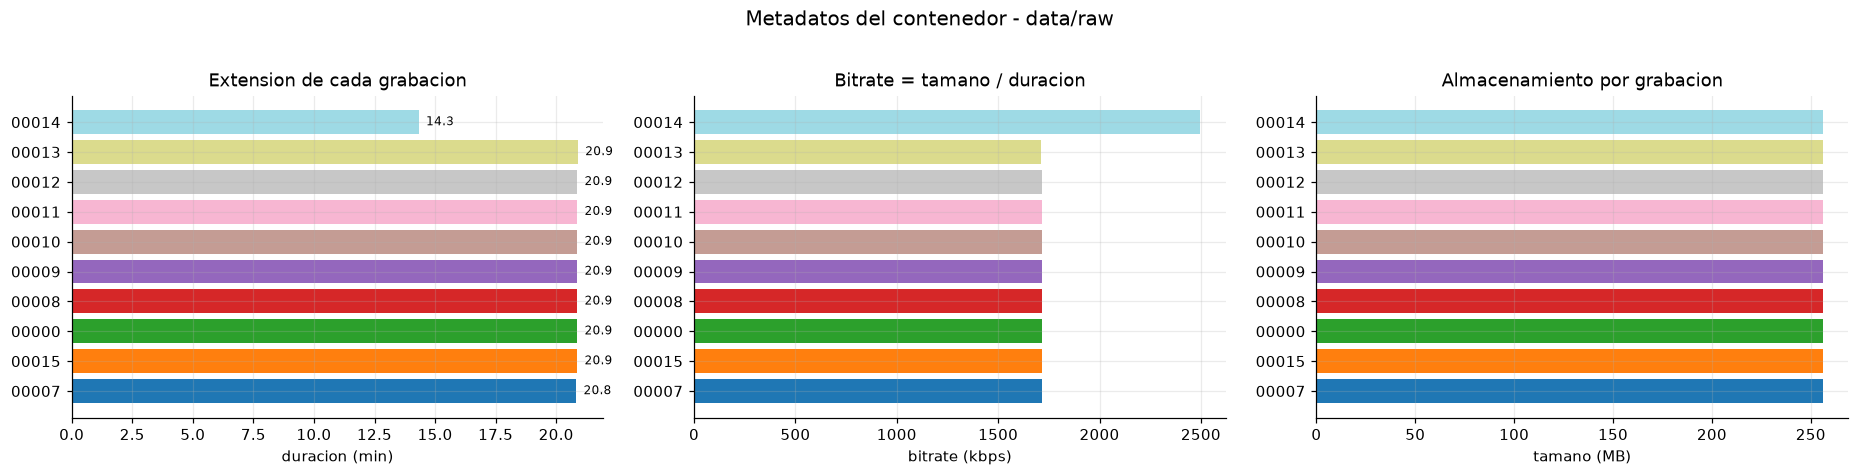

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
etq = meta["camara"].str.replace("tp", "", regex=False)
colores = plt.cm.tab20(np.linspace(0, 1, len(meta)))

axes[0].barh(etq, meta["duracion_min"], color=colores)
axes[0].set_xlabel("duracion (min)")
axes[0].set_title("Extension de cada grabacion")
for y, v in enumerate(meta["duracion_min"]):
    axes[0].text(v + 0.3, y, f"{v:.1f}", va="center", fontsize=8)

axes[1].barh(etq, meta["kbps"], color=colores)
axes[1].set_xlabel("bitrate (kbps)")
axes[1].set_title("Bitrate = tamano / duracion")

axes[2].barh(etq, meta["tamano_mb"], color=colores)
axes[2].set_xlabel("tamano (MB)")
axes[2].set_title("Almacenamiento por grabacion")

fig.suptitle("Metadatos del contenedor - data/raw", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(DIR_OUT / "fig01_metadatos.png", bbox_inches="tight")
plt.show()

## 4. Estrategia de muestreo

Decodificar los ~188 000 fotogramas de los 10 videos tomaria unos 10 minutos solo en lectura.
Como las escenas son **estacionarias en el tiempo** (una camara fija grabando un galpon),
se aplica *seek* directo a los fotogramas de interes:

- El **muestreo principal** usa `MUESTREO_SEGUNDOS` para las metricas de imagen y las transiciones.
- El **barrido denso** usa FPS nativo sobre ventanas cortas para la continuidad (congelamientos,
  fotogramas negros, duplicados exactos que duran pocos segundos).

In [12]:
def leer_fotograma(cap, idx):
    '''Salta a un fotograma por indice y lo lee. Devuelve (ok, frame, t_real).'''
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ok, frame = cap.read()
    t_real = cap.get(cv2.CAP_PROP_POS_MSEC) / 1000.0
    return ok, frame, t_real


# --- verificacion: el salto por indice es preciso? ---
p = VIDEOS[0]
cap = cv2.VideoCapture(str(p))
fps = cap.get(cv2.CAP_PROP_FPS)
objetivos = [0, 137, 902, 5000, 12037, 18700]
errores = []
for idx in objetivos:
    ok, _, t_real = leer_fotograma(cap, idx)
    errores.append(abs(t_real - idx / fps))
cap.release()

verificacion_seek = pd.DataFrame({
    "indice_objetivo": objetivos,
    "error_temporal_s": np.round(errores, 4),
})
print(f"FPS = {fps:.3f} | error maximo de posicionamiento: {max(errores):.4f} s "
      f"({max(errores) * fps:.2f} fotogramas)")
verificacion_seek

FPS = 15.001 | error maximo de posicionamiento: 0.0320 s (0.48 fotogramas)


,indice_objetivo,error_temporal_s
0,0,0.000
1,137,0.026
2,902,0.017
3,5000,0.032
4,12037,0.002
5,18700,0.026


In [13]:
# --- costo comparativo: hacer seek vs. decodificar todo (motiva la estrategia) ---
# Para no tardar un minuto, la decodificacion completa se mide sobre los primeros
# 2000 fotogramas y se extrapola al video completo.
MUESTRAS_DECODIFICADAS = 2000

cap = cv2.VideoCapture(str(p))
n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
objetivos_demo = list(range(0, n_total, int(round(fps * MUESTREO_SEGUNDOS))))

t0 = time.time()
for idx in objetivos_demo:
    leer_fotograma(cap, idx)
t_seek = time.time() - t0
cap.release()

cap = cv2.VideoCapture(str(p))
t0 = time.time()
leidos = 0
while leidos < min(MUESTRAS_DECODIFICADAS, n_total):
    ok, _ = cap.read()
    if not ok:
        break
    leidos += 1
t_seq = time.time() - t0
cap.release()

t_seq_total = t_seq * n_total / leidos

costo_muestreo = pd.DataFrame({
    "estrategia": [f"seek cada {MUESTREO_SEGUNDOS:.0f} s",
                   "decodificacion completa (estimada)"],
    "fotogramas_leidos": [len(objetivos_demo), n_total],
    "segundos": [round(t_seek, 2), round(t_seq_total, 1)],
    "ms_por_fotograma": [round(1000 * t_seek / len(objetivos_demo), 1),
                         round(1000 * t_seq_total / n_total, 2)],
})
costo_muestreo

,estrategia,fotogramas_leidos,segundos,ms_por_fotograma
0,seek cada 5 s,250,7.520,30.100
1,decodificacion completa (estimada),18750,58.900,3.140


## 5. Metricas de fotograma

Implementa las categorias de brillo, exposicion, contraste, nitidez, color, ruido y compresion.

Notas de eficiencia (importantes porque las imagenes son de 1920x1080):

- Los percentiles se calculan sobre una submuestra cada 2 pixeles y se aproximan con el histograma de
  256 niveles: `~0.5 ms` en lugar de `~15 ms` de `np.percentile` sobre la imagen completa.
- `colorfulness`, `densidad_bordes` y `ruido_plano` se calculan sobre una copia reducida
  (`ANCHO_CALIDAD`), porque son medidas de tendencia y no dependen de la resolucion.
- `blockiness` y `ruido` (Immerkaer) si se calculan a resolucion completa, porque dependen del
  tamano del macrobloque y del ruido por pixel.

In [14]:
def percentiles_de_hist(hist, ps=(5, 25, 50, 75, 95)):
    '''Percentiles aproximados desde un histograma de 256 niveles (error <= 1 nivel).'''
    acum = np.cumsum(hist, dtype=np.float64)
    total = acum[-1]
    salida = {}
    for p in ps:
        i = int(np.searchsorted(acum, total * p / 100.0, side="left"))
        salida[f"p{p:02d}"] = float(min(i, 255))
    return salida


def entropia(hist):
    '''Entropia de Shannon (en bits) de un histograma.'''
    p = hist.astype(np.float64) / max(hist.sum(), 1e-9)
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())


def angulo_medio(hist):
    '''Angulo circular medio (grados) de un histograma angular.'''
    ang = (np.arange(len(hist)) + 0.5) * (2 * math.pi / len(hist))
    y = float((hist * np.sin(ang)).sum())
    x = float((hist * np.cos(ang)).sum())
    return float(((math.atan2(y, x) + math.pi) % (2 * math.pi)) * 180 / math.pi)


def dhash(gray, lado=8):
    '''Hash perceptual diferencial de 64 bits, para detectar duplicados.'''
    pequeno = cv2.resize(gray, (lado + 1, lado), interpolation=cv2.INTER_AREA)
    bits = (pequeno[:, 1:] > pequeno[:, :-1]).ravel()
    return np.packbits(bits).tobytes().hex()


def hamming(h1, h2):
    '''Distancia de Hamming entre dos dHash en hexadecimal.'''
    return int(bin(int(h1, 16) ^ int(h2, 16)).count("1"))

In [15]:
def metricas_fotograma(frame, t_seg, idx_foto, ancho_ref):
    '''Todas las metricas de imagen de un fotograma (~40 variables).

    Categorias: brillo, exposicion, contraste, entropia, nitidez, bordes, color,
    ruido, compresion y banderas de calidad.
    '''
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    alto, ancho = gray.shape

    # ---------- histogramas y percentiles ----------
    h_gray = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()
    pct = percentiles_de_hist(h_gray)
    media, desv = cv2.meanStdDev(gray)
    media, desv = float(media.ravel()[0]), float(desv.ravel()[0])
    g_sub = gray[::2, ::2]

    res = {
        "idx": int(idx_foto),
        "t_seg": round(float(t_seg), 3),
        "minuto": round(float(t_seg) / 60, 3),
        "ancho": int(ancho),
        "alto": int(alto),

        # ---- brillo ----
        "brillo_media": media,
        "brillo_mediana": pct["p50"],
        "brillo_std": desv,
        "brillo_p05": pct["p05"],
        "brillo_p25": pct["p25"],
        "brillo_p75": pct["p75"],
        "brillo_p95": pct["p95"],
        "brillo_iqr": pct["p75"] - pct["p25"],
        "rango_dinamico": pct["p95"] - pct["p05"],

        # ---- exposicion ----
        "exposicion": abs(media - 128.0) / 128.0,
        "pct_oscuros": float((g_sub < 16).mean() * 100),
        "pct_claros": float((g_sub > 240).mean() * 100),
        "pct_quemados": float((g_sub >= 250).mean() * 100),

        # ---- contraste y complejidad ----
        "contraste_std": desv,
        "contraste_michelson": (pct["p95"] - pct["p05"]) / (pct["p95"] + pct["p05"] + 1e-6),
        "entropia": entropia(h_gray),

        # ---- nitidez ----
        "nitidez_laplaciano": float(cv2.Laplacian(gray, cv2.CV_64F).var()),
    }

    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    res["nitidez_tenengrad"] = float((gx[::2, ::2] ** 2 + gy[::2, ::2] ** 2).mean())
    res["bordes_debiles"] = float(np.percentile(np.abs(gx[::2, ::2]) + np.abs(gy[::2, ::2]), 95))

    # ---------- color ----------
    rojo, verde, azul = cv2.split(frame)
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    res["saturacion_media"] = float(hsv[:, :, 1].mean())
    res["saturacion_std"] = float(hsv[:, :, 1].std())
    res["valor_medio"] = float(hsv[:, :, 2].mean())
    hist_tono = cv2.calcHist([hsv], [0], None, [36], [0, 180]).ravel()
    res["tono_medio"] = angulo_medio(hist_tono)
    res["entropia_tono"] = entropia(hist_tono)

    # colorfulness (Hasler & Susstrunk) sobre imagen reducida
    if ANCHO_CALIDAD and ancho > ANCHO_CALIDAD:
        f = ANCHO_CALIDAD / ancho
        r2 = cv2.resize(rojo, None, fx=f, fy=f, interpolation=cv2.INTER_AREA).astype(np.float32)
        g2 = cv2.resize(verde, None, fx=f, fy=f, interpolation=cv2.INTER_AREA).astype(np.float32)
        b2 = cv2.resize(azul, None, fx=f, fy=f, interpolation=cv2.INTER_AREA).astype(np.float32)
        gsmall = cv2.resize(gray, (r2.shape[1], r2.shape[0]), interpolation=cv2.INTER_AREA)
    else:
        r2, g2, b2 = rojo.astype(np.float32), verde.astype(np.float32), azul.astype(np.float32)
        gsmall = gray

    res["r_media"], res["g_media"], res["b_media"] = float(r2.mean()), float(g2.mean()), float(b2.mean())
    res["r_std"], res["g_std"], res["b_std"] = float(r2.std()), float(g2.std()), float(b2.std())
    rg = r2 - g2
    yb = 0.5 * (r2 + g2) - b2
    res["colorfulness"] = float(np.sqrt(rg.std() ** 2 + yb.std() ** 2)
                                + 0.3 * np.sqrt(rg.mean() ** 2 + yb.mean() ** 2))
    res["balance_blancos"] = float(r2.mean() - b2.mean())
    res["densidad_bordes"] = float((cv2.Canny(gsmall, 50, 150) > 0).mean() * 100)

    # ---------- ruido ----------
    conv = cv2.filter2D(gray, cv2.CV_32F, KERNEL_RUIDO)
    res["ruido"] = float(np.abs(conv).sum() * math.sqrt(math.pi / 2)
                         / (6 * (ancho - 2) * (alto - 2)))
    lap_abs = np.abs(cv2.Laplacian(gsmall, cv2.CV_32F))
    res["ruido_plano"] = float(np.percentile(lap_abs, 25) / 4.0)

    # ---------- compresion: blockiness 8x8 ----------
    gi = gray.astype(np.int16)
    dx = np.abs(np.diff(gi, axis=1))
    dy = np.abs(np.diff(gi, axis=0))
    res["blockiness"] = float(((dx[:, 7::8].mean() / (dx.mean() + 1e-6))
                               + (dy[7::8, :].mean() / (dy.mean() + 1e-6))) / 2)

    # ---------- banderas ----------
    # OJO: en video comprimido con h264 hay "ringing" en los bordes claros que fija
    # pixeles en 255 aunque la escena NO este sobreexpuesta. Por eso los umbrales
    # de recorte son altos; las anomalias reales se detectan con los flags
    # relativos que se calculan despues (es_brillo_anomalo, es_contraste_bajo).
    res["es_negro"] = bool(res["brillo_media"] < UMBRAL_NEGRO_BRILLO)
    res["es_sobreexpuesto"] = bool(res["pct_quemados"] > UMBRAL_QUEMADOS_PCT
                                   or res["pct_claros"] > UMBRAL_CLAROS_PCT)
    res["es_subexpuesto"] = bool(res["pct_oscuros"] > UMBRAL_ESCUROS_PCT)
    res["dhash"] = dhash(gray)
    res["frame_kib"] = round(frame.nbytes / 1024, 1)
    return res

## 6. Metricas de transicion (movimiento, camara, continuidad, escena, similitud)

Todas se calculan entre **dos fotogramas de muestreo consecutivos**, separados `dt_s` segundos:

- **Movimiento**: diferencia absoluta media, P95 y % de pixeles que cambian.
- **Flujo optico** (Farneback sobre imagen reducida a `ANCHO_FLUJO`): magnitud media, P95 y magnitud
  por segundo, mas la **coherencia** = |flujo medio| / |flujo| medio. Valor alto = todo se mueve
  igual (camara); valor bajo = movimiento local (las gallinas).
- **Estabilidad de camara**: transformacion afin ajustada por RANSAC sobre una reticula de puntos, de
  donde salen traslacion, rotacion y escala. `camara_inliers` indica cuanto del movimiento sigue un
  modelo global. `phaseCorrelate` da el desplazamiento subpixel global.
- **Continuidad**: congelamiento, duplicado perceptual (dHash) y distancia de histogramas.
- **Cambios de escena**: `1 - correlacion(histograma)`.

Las magnitudes de flujo y desplazamiento se reescalan a pixeles de la resolucion completa
(`ANCHO_FLUJO` -> `ancho_ref`) para que sean comparables entre videos.

In [16]:
def metricas_transicion(prev, cur, dt_s, h_prev, h_cur, dh_prev, dh_cur, ancho_ref):
    '''Metricas de la transicion entre dos fotogramas de muestreo consecutivos.'''
    g1 = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(cur, cv2.COLOR_BGR2GRAY)
    dif = cv2.absdiff(g1, g2)
    corr = float(cv2.compareHist(h_prev, h_cur, cv2.HISTCMP_CORREL))
    ham = hamming(dh_prev, dh_cur)

    out = {
        "dt_s": round(float(dt_s), 3),
        "diff_media": float(dif.mean()),
        "diff_p95": float(np.percentile(dif[::2, ::2], 95)),
        "pct_cambiados": float((dif > 10).mean() * 100),
        "hist_correl": corr,
        "corte_escena": bool((1 - corr) > UMBRAL_CORTE_ESCENA),
        "congelado": bool(dif.mean() < UMBRAL_CONGELADO_DIFF),
        "dhash": dh_cur,
        "hamming": ham,
        "duplicado": bool(ham <= UMBRAL_DUPLICADO_HAMMING),
        "desplaz_px_x": np.nan, "desplaz_px_y": np.nan, "desplaz_px": np.nan,
        "desplaz_px_s": np.nan,
        "flujo_mag_media": np.nan, "flujo_mag_p95": np.nan,
        "flujo_por_segundo": np.nan, "flujo_coherencia": np.nan,
        "camara_trasl_x": np.nan, "camara_trasl_y": np.nan,
        "camara_rotacion": np.nan, "camara_escala": np.nan,
        "camara_inliers": 0, "camara_es_global": False,
    }

    # ---------- desplazamiento global subpixel ----------
    h_flujo = max(1, int(round(g1.shape[0] * ANCHO_FLUJO / g1.shape[1])))
    s1 = cv2.resize(g1, (ANCHO_FLUJO, h_flujo), interpolation=cv2.INTER_AREA)
    s2 = cv2.resize(g2, (ANCHO_FLUJO, h_flujo), interpolation=cv2.INTER_AREA)
    escala_ref = ancho_ref / ANCHO_FLUJO

    (px, py), _ = cv2.phaseCorrelate(np.float32(s1), np.float32(s2))
    out["desplaz_px_x"] = float(px * escala_ref)
    out["desplaz_px_y"] = float(py * escala_ref)
    out["desplaz_px"] = float(math.hypot(px, py) * escala_ref)
    out["desplaz_px_s"] = out["desplaz_px"] / max(dt_s, 1e-6)

    if not ANALIZAR_MOVIMIENTO:
        return out

    # ---------- flujo optico denso ----------
    flow = cv2.calcOpticalFlowFarneback(s1, s2, None, pyr_scale=0.5, levels=3,
                                        winsize=15, iterations=3,
                                        poly_n=5, poly_sigma=1.2, flags=0)
    fx, fy = flow[..., 0], flow[..., 1]
    mag, _ang = cv2.cartToPolar(fx, fy)
    mag_mean = float(mag.mean())
    out["flujo_mag_media"] = mag_mean * escala_ref
    out["flujo_mag_p95"] = float(np.percentile(mag[::2, ::2], 95)) * escala_ref
    out["flujo_por_segundo"] = out["flujo_mag_media"] / max(dt_s, 1e-6)
    out["flujo_coherencia"] = float(math.hypot(float(fx.mean()), float(fy.mean()))
                                     / (mag_mean + 1e-6))

    # ---------- modelo global de camara (RANSAC sobre reticula) ----------
    gx, gy = np.meshgrid(np.arange(0, s1.shape[1], 32), np.arange(0, s1.shape[0], 32))
    ix, iy = gx.ravel(), gy.ravel()
    pts = np.stack([ix, iy], axis=1).astype(np.float32)
    M, inliers = cv2.estimateAffinePartial2D(pts, pts + flow[iy, ix],
                                             method=cv2.RANSAC,
                                             ransacReprojThreshold=2.0)
    if M is not None:
        a, b = float(M[0, 0]), float(M[1, 0])
        out["camara_trasl_x"] = float(M[0, 2]) * escala_ref / max(dt_s, 1e-6)
        out["camara_trasl_y"] = float(M[1, 2]) * escala_ref / max(dt_s, 1e-6)
        out["camara_rotacion"] = math.degrees(math.atan2(b, a))
        out["camara_escala"] = math.hypot(a, b)
        out["camara_inliers"] = int(inliers.sum()) if inliers is not None else 0
        out["camara_es_global"] = bool(out["camara_inliers"] >= 0.5 * len(pts))
    out["flujo_puntos"] = len(pts)
    return out

## 7. Ejecucion del analisis sobre `data/raw`

Alimenta cuatro tablas:

| Tabla | Grain | Contenido |
|---|---|---|
| `df_f` | 1 fila por fotograma muestreado | ~45 variables de imagen + banderas |
| `df_t` | 1 fila por par de fotogramas consecutivos | movimiento, camara, cortes, duplicados |
| `df_d` | 1 fila por fotograma del barrido denso | continuidad a FPS nativo |
| `meta` | 1 fila por video | metadatos del contenedor |

In [17]:
def analisis_denso(path, fps, n_ventanas, segundos, ancho_ref, alto_ref):
    '''Barrido a FPS nativo sobre ventanas cortas: negros, congelamientos, duplicados exactos.

    El muestreo principal puede saltarse un congelamiento de 2 s; este barrido no.
    Devuelve una fila por fotograma (comparado con su predecesor inmediato).
    '''
    registros = []
    cap = cv2.VideoCapture(str(path))
    n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    largo = int(segundos * fps)
    tam = (ANCHO_FLUJO, max(1, int(round(ANCHO_FLUJO * alto_ref / ancho_ref))))
    inicios = np.linspace(0, max(0, n_total - largo), n_ventanas).astype(int)

    for v, ini in enumerate(inicios):
        ok, frame, _ = leer_fotograma(cap, int(ini))
        if not ok:
            continue
        prev = cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), tam,
                          interpolation=cv2.INTER_AREA)
        prev_dh = dhash(prev)
        racha = 0

        for j in range(1, largo):
            ok, frame = cap.read()
            if not ok:
                break
            g = cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), tam,
                           interpolation=cv2.INTER_AREA)
            d = float(cv2.absdiff(prev, g).mean())
            brillo = float(g.mean())
            h = hamming(prev_dh, dhash(g))
            # racha de fotogramas perceptualmente IDENTICOS al anterior.
            # En una escena estatica esto es normal (el codec repite el frame);
            # una racha larga es lo que delata una grabacion detenida (stall).
            racha = racha + 1 if h == 0 else 0
            registros.append({
                "ventana": v,
                "idx": int(ini + j),
                "t_seg": round((ini + j) / fps, 3),
                "dif_media": d,
                "brillo": brillo,
                "negro": bool(brillo < UMBRAL_NEGRO_BRILLO),
                "congelado": bool(d < UMBRAL_CONGELADO_DIFF),
                "hamming": h,
                "identico": bool(h == 0),
                "racha_identicos": racha,
                "es_stall": bool(racha >= UMBRAL_RACHA_STALL),
            })
            prev, prev_dh = g, dhash(g)
    cap.release()
    return pd.DataFrame(registros)

In [18]:
def analizar_video(path, muestreo_s=MUESTREO_SEGUNDOS, max_frames=MAX_FRAMES_VIDEO):
    '''Analiza un video: metadatos + metricas de fotogramas + metricas de transicion + denso.'''
    md_ = leer_metadatos(path)
    fps, total = md_["fps_real"], md_["fotogramas"]
    paso = max(1, int(round(fps * muestreo_s)))

    cap = cv2.VideoCapture(str(path))
    filas, transiciones = [], []
    prev = prev_hist = prev_dh = None
    t_previo = 0.0

    for idx in range(0, total, paso):
        ok, frame, t_real = leer_fotograma(cap, idx)
        if not ok:
            break
        hist = cv2.calcHist([cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)], [0], None,
                            [64], [0, 256])
        st = metricas_fotograma(frame, idx / fps, idx, md_["ancho"])
        st["t_real"] = round(float(t_real), 3)

        if prev is not None:
            tr = metricas_transicion(prev, frame, idx / fps - t_previo,
                                     prev_hist, hist, prev_dh, st["dhash"],
                                     md_["ancho"])
            tr["idx"], tr["t_seg"] = st["idx"], st["t_seg"]
            transiciones.append(tr)

        filas.append(st)
        prev, prev_hist, prev_dh, t_previo = frame, hist, st["dhash"], idx / fps
        if max_frames and len(filas) >= max_frames:
            break
    cap.release()

    ident = {"video": path.name, "stem": path.stem,
             "camara": parse_stem(path.stem)["camara"]}
    df_f = pd.DataFrame(filas)
    df_t = pd.DataFrame(transiciones)
    for k, v in ident.items():
        df_f.insert(0, k, v)
        if len(df_t):
            df_t.insert(0, k, v)

    df_d = pd.DataFrame()
    if ANALIZAR_DENSIDAD and not max_frames:
        df_d = analisis_denso(path, fps, N_VENTANAS_DENSAS, SEGUNDOS_DENSOS,
                               md_["ancho"], md_["alto"])
        for k, v in ident.items():
            if len(df_d):
                df_d.insert(0, k, v)

    print(f"  {path.name:32s} fps={fps:6.2f} muestreados={len(df_f):4d} "
          f"transiciones={len(df_t):4d} densos={len(df_d):5d}")
    return df_f, df_t, df_d

In [19]:
def ejecutar_eda(reutilizar_cache=True):
    '''Ejecuta (o reutiliza desde cache) el EDA de todos los videos.'''
    archivos = VIDEOS[:LIMITE_VIDEOS] if LIMITE_VIDEOS else VIDEOS
    nombres = {p.name for p in archivos}

    cache = {k: DIR_OUT / f"eda_{k}.csv"
             for k in ["fotogramas", "transiciones", "denso"]}

    if reutilizar_cache and cache["fotogramas"].exists() and cache["transiciones"].exists():
        df_f = pd.read_csv(cache["fotogramas"])
        df_t = pd.read_csv(cache["transiciones"])
        df_d = pd.read_csv(cache["denso"]) if cache["denso"].exists() else pd.DataFrame()
        if nombres.issubset(set(df_f["video"].unique())):
            print(f"Cache reutilizado: {len(df_f):,} fotogramas y {len(df_t):,} transiciones")
            return (df_f[df_f["video"].isin(nombres)].reset_index(drop=True),
                    df_t[df_t["video"].isin(nombres)].reset_index(drop=True), df_d)
        print("Cache incompleto para los videos pedidos; se recalcula...")

    print(f"Analizando {len(archivos)} videos (puede tardar varios minutos)...\n")
    t0 = time.time()
    F, T, D = [], [], []
    for p in archivos:
        f, t, d = analizar_video(p)
        F.append(f)
        if len(t):
            T.append(t)
        if len(d):
            D.append(d)

    df_f = pd.concat(F, ignore_index=True) if F else pd.DataFrame()
    df_t = pd.concat(T, ignore_index=True) if T else pd.DataFrame()
    df_d = pd.concat(D, ignore_index=True) if D else pd.DataFrame()
    print(f"\nTiempo total: {time.time() - t0:,.1f} s")

    df_f.to_csv(cache["fotogramas"], index=False)
    df_t.to_csv(cache["transiciones"], index=False)
    if len(df_d):
        df_d.to_csv(cache["denso"], index=False)
    print(f"Cache escrito en {DIR_OUT}")
    return df_f, df_t, df_d

In [20]:
df_f, df_t, df_d = ejecutar_eda(reutilizar_cache=True)

print(f"\ndf_fotogramas  : {df_f.shape}")
print(f"df_transiciones: {df_t.shape}")
print(f"df_denso       : {df_d.shape}")
print("\nVariables de df_fotogramas:")
list(df_f.columns)

Analizando 10 videos (puede tardar varios minutos)...



  20240805_215845_tp00007.mp4      fps= 15.00 muestreados= 250 transiciones= 249 densos=  898


  20240805_215845_tp00015.mp4      fps= 15.00 muestreados= 251 transiciones= 250 densos=  898


  20260727_173621_tp00000.mp4      fps= 15.00 muestreados= 251 transiciones= 250 densos=  898


  20260728_064628_tp00008.mp4      fps= 15.00 muestreados= 251 transiciones= 250 densos=  898


...

  20260728_074904_tp00011.mp4      fps= 15.00 muestreados= 251 transiciones= 250 densos=  896


  20260728_080956_tp00012.mp4      fps= 15.00 muestreados= 251 transiciones= 250 densos=  898


  20260728_083048_tp00013.mp4      fps= 15.00 muestreados= 251 transiciones= 250 densos=  898


  20260728_085142_tp00014.mp4      fps= 15.00 muestreados= 172 transiciones= 171 densos=  898

Tiempo total: 319.3 s
Cache escrito en B:\11RossyDocumentos\18ProyectoPollos\12Avances\11_proyecto_pollos\artifacts\eda_videos

df_fotogramas  : (2430, 50)
df_transiciones: (2420, 30)
df_denso       : (8978, 14)

Variables de df_fotogramas:


['camara',
 'stem',
 'video',
 'idx',
 't_seg',
 'minuto',
 'ancho',
 'alto',
 'brillo_media',
 'brillo_mediana',
 'brillo_std',
 'brillo_p05',
 'brillo_p25',
 'brillo_p75',
 'brillo_p95',
 'brillo_iqr',
 'rango_dinamico',
 'exposicion',
 'pct_oscuros',
 'pct_claros',
 'pct_quemados',
 'contraste_std',
 'contraste_michelson',
 'entropia',
 'nitidez_laplaciano',
 'nitidez_tenengrad',
 'bordes_debiles',
 'saturacion_media',
 'saturacion_std',
 'valor_medio',
 'tono_medio',
 'entropia_tono',
 'r_media',
 'g_media',
 'b_media',
 'r_std',
 'g_std',
 'b_std',
 'colorfulness',
 'balance_blancos',
 'densidad_bordes',
 'ruido',
 'ruido_plano',
 'blockiness',
 'es_negro',
 'es_sobreexpuesto',
 'es_subexpuesto',
 'dhash',
 'frame_kib',
 't_real']

In [21]:
print("Primeras filas (muestra de columnas clave):")
df_f[["video", "t_seg", "brillo_media", "brillo_p95", "exposicion", "contraste_std",
      "entropia", "nitidez_laplaciano", "colorfulness", "saturacion_media",
      "ruido", "blockiness", "es_negro"]].head(8)

Primeras filas (muestra de columnas clave):


,video,t_seg,brillo_media,brillo_p95,exposicion,contraste_std,entropia,nitidez_laplaciano,colorfulness,saturacion_media,ruido,blockiness,es_negro
0,20240805_215845_tp00007.mp4,0.000,104.240,213.000,0.186,53.739,7.387,918.133,22.232,25.911,1.345,1.255,False
1,20240805_215845_tp00007.mp4,5.000,105.127,214.000,0.179,53.764,7.392,847.216,21.682,25.336,1.276,1.146,False
2,20240805_215845_tp00007.mp4,9.999,107.580,229.000,0.160,55.973,7.393,970.286,22.089,25.685,1.400,1.325,False
3,20240805_215845_tp00007.mp4,14.999,106.252,217.000,0.170,53.824,7.374,817.885,21.923,25.952,1.190,1.121,False
4,20240805_215845_tp00007.mp4,19.999,95.909,255.000,0.251,63.191,6.965,388.320,7.154,15.396,0.346,1.256,False
5,20240805_215845_tp00007.mp4,24.998,105.345,213.000,0.177,52.855,7.355,884.832,21.956,26.118,1.277,1.176,False
6,20240805_215845_tp00007.mp4,29.998,105.174,214.000,0.178,52.898,7.347,986.420,22.142,25.566,1.411,1.231,False
7,20240805_215845_tp00007.mp4,34.998,105.604,213.000,0.175,52.619,7.345,945.097,21.900,25.657,1.395,1.192,False


## 8. Agregacion y variables derivadas

Se anaden al dataset:

- `nitidez_relativa`: nitidez normalizada dentro de cada video (permite comparar entre videos).
- `nivel_luz` y `nivel_movimiento`: categorias discretas para segmentar.
- `brillo_relativo`, `contraste_relativo`, `es_brillo_anomalo`, `es_contraste_bajo`: banderas
  **relativas a la mediana del video**, que detectan fotogramas atipicos de forma independiente de
  la iluminacion general de cada grabacion.
- Estadisticas de la tabla de transiciones replicadas por fotograma (movimiento y camara).
- **`calidad_global`**: score 0-100 con los pesos de `PESOS_CALIDAD`.

In [22]:
def detectar_cortes(df_t, k=K_MAD_CORTE):
    '''Corte de escena por umbral fijo y por umbral adaptativo (MAD robusto).

    El umbral fijo no escala bien entre videos con distinta iluminacion. El
    adaptativo usa mediana + k * sigma robusta (sigma = 1.4826 * MAD), que es
    inmune a los propios valores extremos y por tanto mas fiable.
    '''
    if not len(df_t):
        return df_t
    df = df_t.copy()
    df["dist_hist"] = 1.0 - df["hist_correl"]

    def umbral(s):
        med = s.median()
        mad = (s - med).abs().median()
        return med + k * 1.4826 * mad

    df["umbral_corte_adaptivo"] = df.groupby("video")["dist_hist"].transform(umbral)
    df["corte_escena_adaptivo"] = df["dist_hist"] > df["umbral_corte_adaptivo"]
    df["z_robusto_hist"] = ((df["dist_hist"] - df.groupby("video")["dist_hist"].transform("median"))
                            / (1.4826 * df.groupby("video")["dist_hist"]
                               .transform(lambda s: (s - s.median()).abs().median()) + 1e-9))
    return df


df_t = detectar_cortes(df_t)
print(f"Transiciones: {len(df_t):,}")
print(f"Cortes con umbral fijo ({UMBRAL_CORTE_ESCENA})     : {int(df_t['corte_escena'].sum())}")
print(f"Cortes con umbral adaptativo (k={K_MAD_CORTE} MAD)  : {int(df_t['corte_escena_adaptivo'].sum())}")
df_t[["video", "t_seg", "dist_hist", "umbral_corte_adaptivo",
      "z_robusto_hist", "corte_escena", "corte_escena_adaptivo"]].head(10)

Transiciones: 2,420
Cortes con umbral fijo (0.1)     : 6
Cortes con umbral adaptativo (k=6.0 MAD)  : 69


,video,t_seg,dist_hist,umbral_corte_adaptivo,z_robusto_hist,corte_escena,corte_escena_adaptivo
0,20240805_215845_tp00007.mp4,5.000,0.002,0.006,0.038,False,False
1,20240805_215845_tp00007.mp4,9.999,0.006,0.006,6.665,False,True
2,20240805_215845_tp00007.mp4,14.999,0.004,0.006,3.035,False,False
3,20240805_215845_tp00007.mp4,19.999,0.211,0.006,296.604,True,True
4,20240805_215845_tp00007.mp4,24.998,0.209,0.006,293.343,True,True
5,20240805_215845_tp00007.mp4,29.998,0.002,0.006,0.641,False,False
6,20240805_215845_tp00007.mp4,34.998,0.002,0.006,-0.081,False,False
7,20240805_215845_tp00007.mp4,39.997,0.002,0.006,0.637,False,False
8,20240805_215845_tp00007.mp4,44.997,0.002,0.006,-0.123,False,False
9,20240805_215845_tp00007.mp4,49.997,0.002,0.006,0.471,False,False


In [23]:
def derivar_banderas(df_f, df_t):
    '''Anade nitidez relativa, categorias de nivel y score de calidad global.'''
    df = df_f.copy()

    # nitidez relativa dentro del video (permite comparar entre videos)
    p90 = df.groupby("video")["nitidez_laplaciano"].transform(lambda s: s.quantile(0.90))
    df["nitidez_relativa"] = (df["nitidez_laplaciano"] / p90.replace(0, np.nan)).clip(0, 2)
    df["es_borroso"] = df["nitidez_relativa"] < UMBRAL_BORROSO_REL

    # ---- anomalias relativas a la mediana del propio video ----
    # Son mas utiles que los umbrales absolutos: detectan fotogramas atipicos
    # aunque el video completo sea muy claro o muy oscuro.
    med_brillo = df.groupby("video")["brillo_media"].transform("median")
    med_contraste = df.groupby("video")["contraste_std"].transform("median")
    df["brillo_relativo"] = df["brillo_media"] / med_brillo.replace(0, np.nan)
    df["es_brillo_anomalo"] = (df["brillo_relativo"] - 1).abs() > UMBRAL_BRILLO_REL
    df["contraste_relativo"] = df["contraste_std"] / med_contraste.replace(0, np.nan)
    df["es_contraste_bajo"] = df["contraste_relativo"] < UMBRAL_CONTRASTE_REL

    df["nivel_luz"] = pd.cut(df["brillo_media"], bins=[-np.inf, 40, 80, 120, 170, np.inf],
                             labels=["muy_oscuro", "oscuro", "medio", "claro", "muy_claro"])

    if len(df_t):
        g = df_t.groupby("video")
        df = df.merge(
            g.agg(cortes_escena=("corte_escena", "sum"),
                  pct_congelados=("congelado", lambda s: 100 * s.mean()),
                  pct_duplicados=("duplicado", lambda s: 100 * s.mean()),
                  dif_media_prom=("diff_media", "mean"),
                  flujo_medio=("flujo_mag_media", "mean"),
                  coherencia_medio=("flujo_coherencia", "mean")).reset_index(),
            on="video", how="left")
        sac = g.agg(sacudida_px=("desplaz_px", "std"),
                    rotacion_std=("camara_rotacion", "std"),
                    rotacion_max=("camara_rotacion", lambda s: s.abs().max()),
                    escala_std=("camara_escala", "std"),
                    pct_mov_global=("camara_es_global", lambda s: 100 * s.mean()),
                    hist_correl_media=("hist_correl", "mean")).reset_index()
        df = df.merge(sac, on="video", how="left")
    else:
        for c in ["cortes_escena", "pct_congelados", "pct_duplicados", "dif_media_prom",
                  "flujo_medio", "coherencia_medio", "sacudida_px", "rotacion_std",
                  "rotacion_max", "escala_std", "pct_mov_global", "hist_correl_media"]:
            df[c] = np.nan

    df["nivel_movimiento"] = pd.cut(df["dif_media_prom"].fillna(0),
                                    bins=[-np.inf, 2, 8, 20, np.inf],
                                    labels=["quieto", "leve", "moderado", "intenso"])

    # ---------- score de calidad 0-100 ----------
    comp = {
        "nitidez": df["nitidez_relativa"].clip(0, 1),
        "exposicion": 1 - df["exposicion"].clip(0, 1),
        "contraste": (df["contraste_std"] / 60.0).clip(0, 1),
        "color": (df["colorfulness"] / 40.0).clip(0, 1),
        "estabilidad": 1 - (df["sacudida_px"].fillna(0) / 8.0).clip(0, 1),
    }
    df["calidad_global"] = 100 * sum(PESOS_CALIDAD[k] * v for k, v in comp.items())
    return df


df_f = derivar_banderas(df_f, df_t)
print(f"{len(df_f):,} fotogramas | {df_f['video'].nunique()} videos")
print(f"Columnas: {df_f.shape[1]}")
df_f.columns.tolist()

2,430 fotogramas | 10 videos
Columnas: 71


['camara',
 'stem',
 'video',
 'idx',
 't_seg',
 'minuto',
 'ancho',
 'alto',
 'brillo_media',
 'brillo_mediana',
 'brillo_std',
 'brillo_p05',
 'brillo_p25',
 'brillo_p75',
 'brillo_p95',
 'brillo_iqr',
 'rango_dinamico',
 'exposicion',
 'pct_oscuros',
 'pct_claros',
 'pct_quemados',
 'contraste_std',
 'contraste_michelson',
 'entropia',
 'nitidez_laplaciano',
 'nitidez_tenengrad',
 'bordes_debiles',
 'saturacion_media',
 'saturacion_std',
 'valor_medio',
 'tono_medio',
 'entropia_tono',
 'r_media',
 'g_media',
 'b_media',
 'r_std',
 'g_std',
 'b_std',
 'colorfulness',
 'balance_blancos',
 'densidad_bordes',
 'ruido',
 'ruido_plano',
 'blockiness',
 'es_negro',
 'es_sobreexpuesto',
 'es_subexpuesto',
 'dhash',
 'frame_kib',
 't_real',
 'nitidez_relativa',
 'es_borroso',
 'brillo_relativo',
 'es_brillo_anomalo',
 'contraste_relativo',
 'es_contraste_bajo',
 'nivel_luz',
 'cortes_escena',
 'pct_congelados',
 'pct_duplicados',
 'dif_media_prom',
 'flujo_medio',
 'coherencia_medio',
 'sac

In [24]:
def resumen_por_video(df_f, df_t, df_d):
    '''Una fila por video con estadisticas agregadas de todas las categorias.'''
    def pct(s):
        return 100 * s.mean()

    base = df_f.groupby(["video", "camara"], as_index=False).agg(
        fotogramas=("idx", "size"),
        duracion_min=("t_seg", lambda s: s.max() / 60),
        brillo_p05=("brillo_media", lambda s: s.quantile(0.05)),
        brillo_p50=("brillo_media", "median"),
        brillo_p95=("brillo_media", lambda s: s.quantile(0.95)),
        brillo_std_entre=("brillo_media", "std"),
        pct_oscuros_p50=("pct_oscuros", "median"),
        pct_quemados_max=("pct_quemados", "max"),
        exposicion_p50=("exposicion", "median"),
        contraste_p50=("contraste_std", "median"),
        rango_din_p50=("rango_dinamico", "median"),
        entropia_p50=("entropia", "median"),
        nitidez_p50=("nitidez_laplaciano", "median"),
        nitidez_rel_p50=("nitidez_relativa", "median"),
        ruido_p50=("ruido", "median"),
        ruido_max=("ruido", "max"),
        blockiness_p50=("blockiness", "median"),
        colorfulness_p50=("colorfulness", "median"),
        saturacion_p50=("saturacion_media", "median"),
        tono_p50=("tono_medio", "median"),
        balance_blancos_p50=("balance_blancos", "median"),
        pct_borrosos=("es_borroso", pct),
        pct_brillo_anomalos=("es_brillo_anomalo", pct),
        pct_contraste_bajo=("es_contraste_bajo", pct),
        pct_subexpuestos=("es_subexpuesto", pct),
        pct_sobreexpuestos=("es_sobreexpuesto", pct),
        pct_negros=("es_negro", pct),
        calidad_p50=("calidad_global", "median"),
    )

    if len(df_t):
        base = base.merge(
            df_t.groupby("video", as_index=False).agg(
                cortes_escena=("corte_escena", "sum"),
                cortes_adaptativos=("corte_escena_adaptivo", "sum"),
                pct_congelados=("congelado", pct),
                pct_duplicados=("duplicado", pct),
                flujo_por_seg_p50=("flujo_por_segundo", "median"),
                coherencia_p50=("flujo_coherencia", "median"),
                pct_cambiados_p50=("pct_cambiados", "median"),
                sacudida_px_p50=("desplaz_px", "median"),
                sacudida_px_max=("desplaz_px", "max"),
                rotacion_max=("camara_rotacion", lambda s: s.abs().max()),
                pct_mov_global=("camara_es_global", pct),
                hist_correl_p50=("hist_correl", "median")),
            on="video", how="left")

    if len(df_d):
        base = base.merge(
            df_d.groupby("video", as_index=False).agg(
                idx_densos=("dif_media", "size"),
                negros_densos=("negro", "sum"),
                pct_negros_denso=("negro", pct),
                pct_congelados_denso=("congelado", pct),
                pct_identicos_denso=("identico", pct),
                racha_identicos_max=("racha_identicos", "max"),
                pct_stall=("es_stall", pct),
                dif_densa_p50=("dif_media", "median")),
            on="video", how="left")

    base["duracion_min"] = base["duracion_min"].round(2)
    base["fecha"] = base["video"].map(lambda v: parse_stem(Path(v).stem)["fecha"])
    base["hora"] = base["video"].map(lambda v: parse_stem(Path(v).stem)["hora"])
    return base.sort_values("video").reset_index(drop=True)


resumen_video = resumen_por_video(df_f, df_t, df_d)
resumen_video.to_csv(DIR_OUT / "eda_resumen_por_video.csv", index=False)
resumen_video

,video,camara,fotogramas,duracion_min,brillo_p05,brillo_p50,brillo_p95,brillo_std_entre,pct_oscuros_p50,pct_quemados_max,exposicion_p50,contraste_p50,rango_din_p50,entropia_p50,nitidez_p50,nitidez_rel_p50,ruido_p50,ruido_max,blockiness_p50,colorfulness_p50,saturacion_p50,tono_p50,balance_blancos_p50,pct_borrosos,pct_brillo_anomalos,pct_contraste_bajo,pct_subexpuestos,pct_sobreexpuestos,pct_negros,calidad_p50,cortes_escena,cortes_adaptativos,pct_congelados,pct_duplicados,flujo_por_seg_p50,coherencia_p50,pct_cambiados_p50,sacudida_px_p50,sacudida_px_max,rotacion_max,pct_mov_global,hist_correl_p50,idx_densos,negros_densos,pct_negros_denso,pct_congelados_denso,pct_identicos_denso,racha_identicos_max,pct_stall,dif_densa_p50,fecha,hora
0,20240805_215845_tp00007.mp4,tp00007,250,20.750,106.459,111.955,115.109,2.749,0.150,6.739,0.125,48.392,155.000,7.293,958.855,0.917,1.375,1.623,1.199,25.623,26.795,169.916,-10.078,0.400,0.000,0.000,0.000,0.400,0.000,81.732,2,8,0.000,27.309,1.046,0.285,49.522,0.980,55.625,4.916,99.197,0.998,898,0,0.000,0.000,45.323,13,0.000,2.035,2024-08-05,21:58:45
1,20240805_215845_tp00015.mp4,tp00015,251,20.830,118.955,120.687,122.572,1.278,0.314,5.753,0.057,45.728,147.000,7.192,"1,448.583",0.905,2.081,2.502,1.226,26.865,33.197,126.222,-4.207,0.398,0.000,1.195,0.000,0.398,0.000,86.356,4,12,0.000,33.600,1.074,0.210,51.713,0.696,6.665,4.490,98.800,0.998,898,0,0.000,0.000,38.530,11,0.000,2.118,2024-08-05,21:58:45
2,20260727_173621_tp00000.mp4,tp00000,251,20.830,106.425,110.088,114.914,2.325,0.117,4.280,0.140,42.055,131.000,7.052,880.478,0.943,1.232,1.495,1.199,23.062,23.399,179.866,-9.599,0.000,0.000,0.000,0.000,0.000,0.000,74.395,0,20,0.000,20.800,1.114,0.197,46.045,0.565,179.334,2.096,99.200,0.998,898,0,0.000,0.000,42.762,11,0.000,1.854,2026-07-27,17:36:21
3,20260728_064628_tp00008.mp4,tp00008,251,20.830,114.357,117.593,120.136,1.775,0.138,2.226,0.081,44.353,142.000,7.151,969.774,0.938,1.340,1.574,1.202,25.718,25.899,181.030,-11.197,0.000,0.000,0.000,0.000,0.000,0.000,86.351,0,1,0.000,29.600,1.157,0.243,46.503,0.868,2.481,0.242,100.000,0.998,898,0,0.000,0.000,49.555,16,0.223,1.746,2026-07-28,06:46:28
4,20260728_070720_tp00009.mp4,tp00009,251,20.830,113.372,117.148,119.972,1.922,0.150,2.562,0.085,43.278,139.000,7.106,954.791,0.946,1.327,1.559,1.189,26.182,25.737,183.430,-11.286,0.000,0.000,0.000,0.000,0.000,0.000,86.023,0,3,0.000,30.400,1.193,0.219,44.328,0.742,5.940,0.218,100.000,0.998,898,0,0.000,0.000,57.016,12,0.000,1.773,2026-07-28,07:07:20
5,20260728_072812_tp00010.mp4,tp00010,251,20.830,115.668,118.215,120.244,1.457,0.180,2.982,0.076,45.227,148.000,7.118,"1,071.682",0.922,1.548,1.791,1.203,30.472,37.653,181.916,-15.831,0.000,0.000,0.000,0.000,0.000,0.000,87.658,0,4,0.000,26.000,1.056,0.192,48.056,0.643,1.856,0.219,100.000,0.998,898,0,0.000,0.000,52.004,9,0.000,1.625,2026-07-28,07:28:12
6,20260728_074904_tp00011.mp4,tp00011,251,20.840,118.103,119.685,121.552,1.064,0.154,2.307,0.065,43.227,140.000,7.081,"1,060.692",0.927,1.562,1.841,1.158,29.805,36.967,180.980,-14.614,0.000,0.000,0.000,0.000,0.000,0.000,87.199,0,6,0.000,25.600,1.060,0.179,45.707,0.522,2.008,0.239,100.000,0.999,896,0,0.000,0.000,55.915,22,0.893,1.448,2026-07-28,07:49:04
7,20260728_080956_tp00012.mp4,tp00012,251,20.830,121.022,123.266,125.641,1.560,0.158,2.270,0.037,42.885,137.000,7.075,"1,236.864",0.916,1.834,2.101,1.201,31.775,41.700,184.170,-18.906,0.000,0.000,0.000,0.000,0.000,0.000,87.969,0,6,0.000,32.800,0.989,0.164,46.422,0.524,2.038,0.133,100.000,0.999,898,0,0.000,0.000,56.459,15,0.111,1.398,2026-07-28,08:09:56
8,20260728_083048_tp00013.mp4,tp00013,251,20.830,119.526,124.919,130.712,3.418,0.220,2.835,0.026,42.493,135.000,7.093,"1,602.910",0.831,2.280,3.113,1.227,27.782,31.792,138.504,-7.482,0.000,0.000,0.000,0.000,0.000,0.000,83.771,0,8,0.000,21.600,1.169,0.189,47.169,0.627,2.068,0.254,100.000,0.998,898,0,0.000,0.000,47.216,16,0.223,2.214,2026-07-28,08:30:48
9,20260728_085142_tp00014.mp4,tp00014,172,14.250,120.569,123.777,126.301,1.776,0.24

In [25]:
resumen_video.set_index("video")[[
    "duracion_min", "brillo_p50", "exposicion_p50", "contraste_p50", "rango_din_p50",
    "entropia_p50", "nitidez_p50", "ruido_p50", "blockiness_p50", "colorfulness_p50",
    "saturacion_p50", "tono_p50", "calidad_p50", "pct_borrosos",
]].T.round(3)

video,20240805_215845_tp00007.mp4,20240805_215845_tp00015.mp4,20260727_173621_tp00000.mp4,20260728_064628_tp00008.mp4,20260728_070720_tp00009.mp4,20260728_072812_tp00010.mp4,20260728_074904_tp00011.mp4,20260728_080956_tp00012.mp4,20260728_083048_tp00013.mp4,20260728_085142_tp00014.mp4
duracion_min,20.750,20.830,20.830,20.830,20.830,20.830,20.840,20.830,20.830,14.250
brillo_p50,111.955,120.687,110.088,117.593,117.148,118.215,119.685,123.266,124.919,123.777
exposicion_p50,0.125,0.057,0.140,0.081,0.085,0.076,0.065,0.037,0.026,0.033
contraste_p50,48.392,45.728,42.055,44.353,43.278,45.227,43.227,42.885,42.493,45.056
rango_din_p50,155.000,147.000,131.000,142.000,139.000,148.000,140.000,137.000,135.000,145.000
entropia_p50,7.293,7.192,7.052,7.151,7.106,7.118,7.081,7.075,7.093,7.165
nitidez_p50,958.855,"1,448.583",880.478,969.774,954.791,"1,071.682","1,060.692","1,236.864","1,602.910","1,524.840"
ruido_p50,1.375,2.081,1.232,1.340,1.327,1.548,1.562,1.834,2.280,2.158
blockiness_p50,1.199,1.226,1.199,1.202,1.189,1.203,1.158,1.201,1.227,1.254
colorfulness_p50,25.623,26.865,23.062,25.718,26.182,30.472,29.805,31.775,27.782,26.485


## 9. Distribuciones por categoria

Boxplots por camara. Permiten comprobar si las 10 grabaciones son homogeneas, que es la
informacion clave para decidir si basta un solo modelo o si hay que estratificar por camara/fecha.

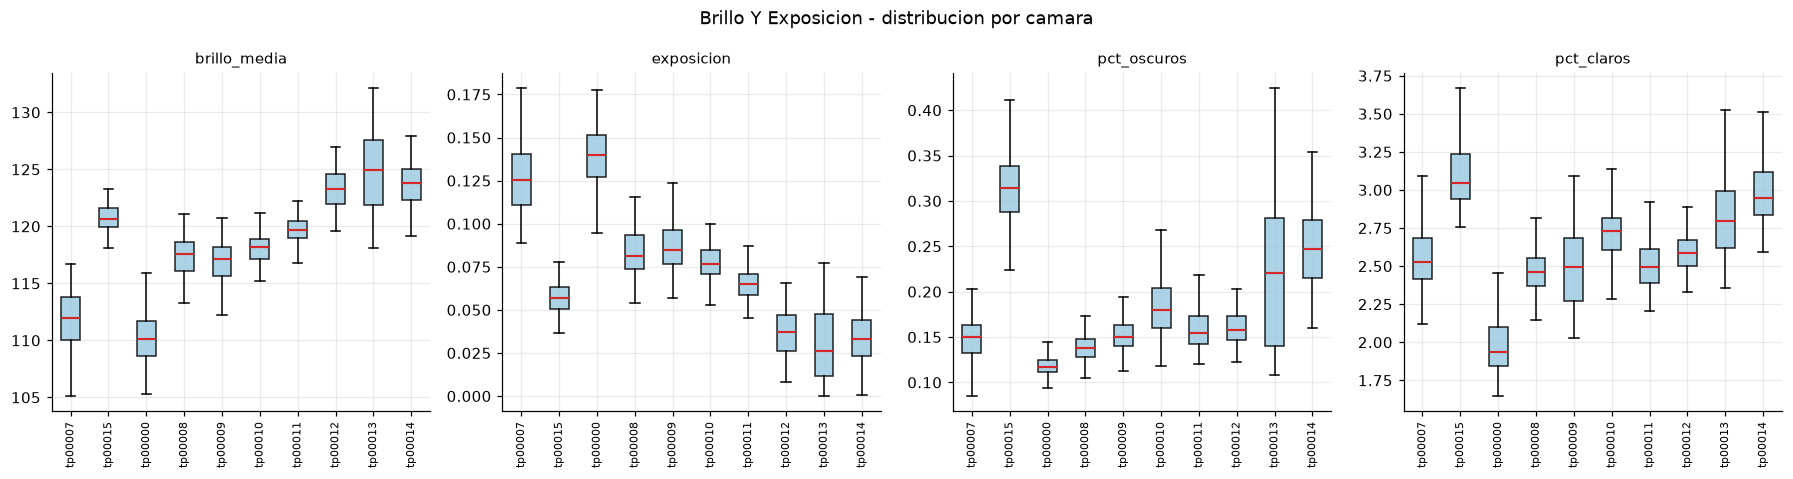

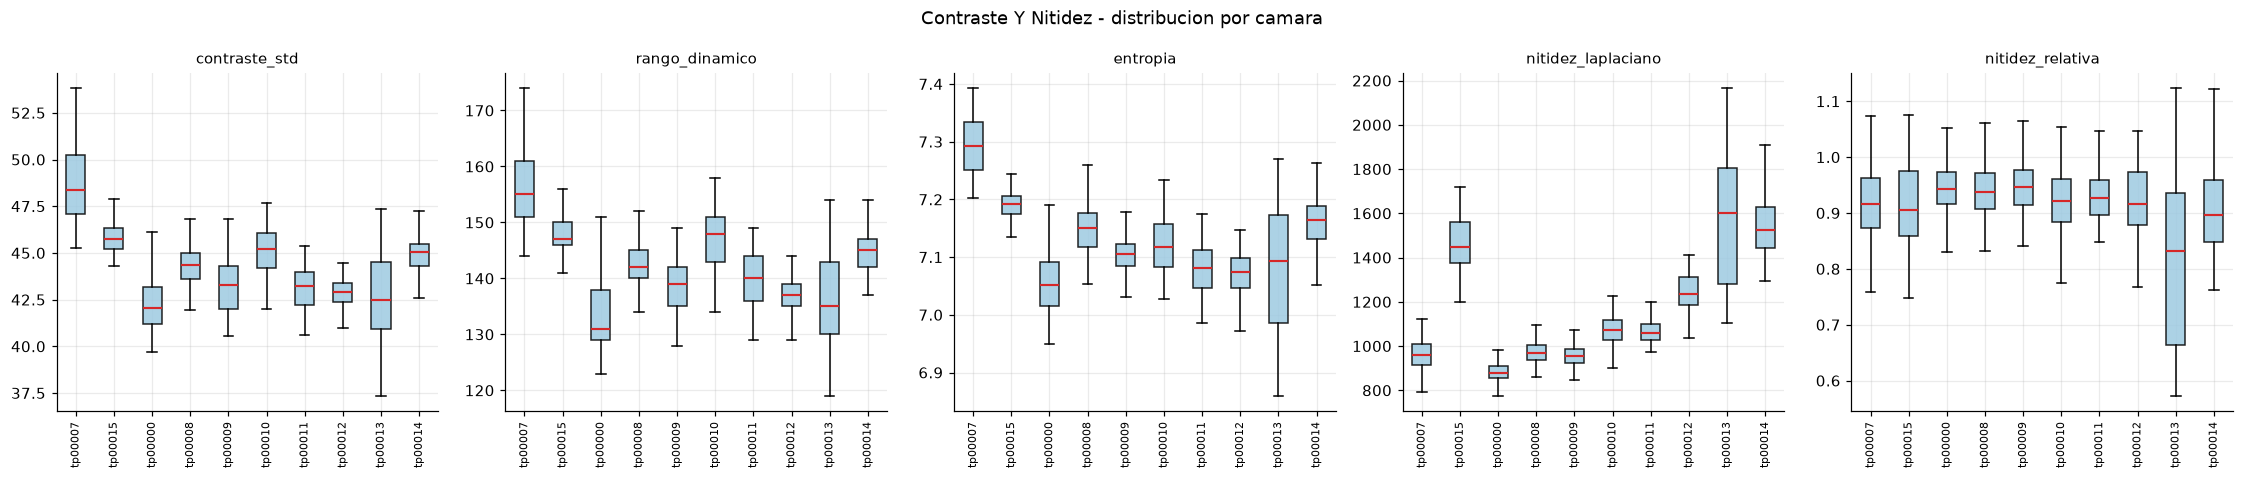

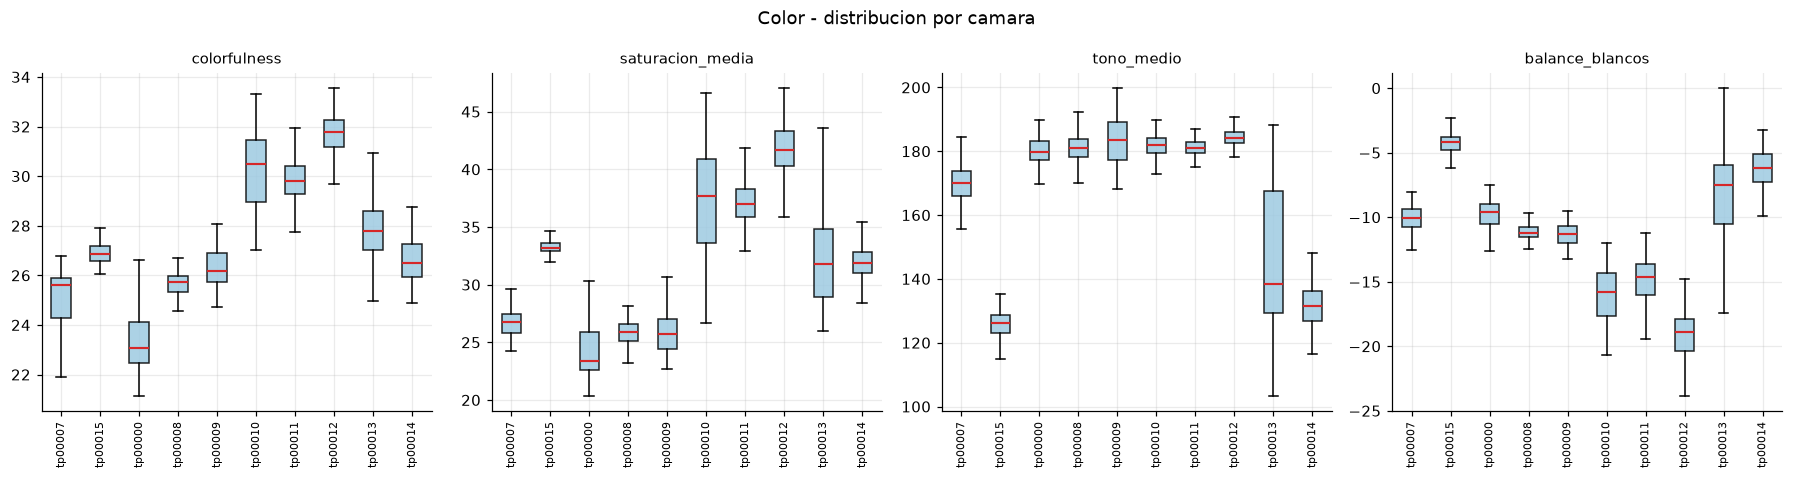

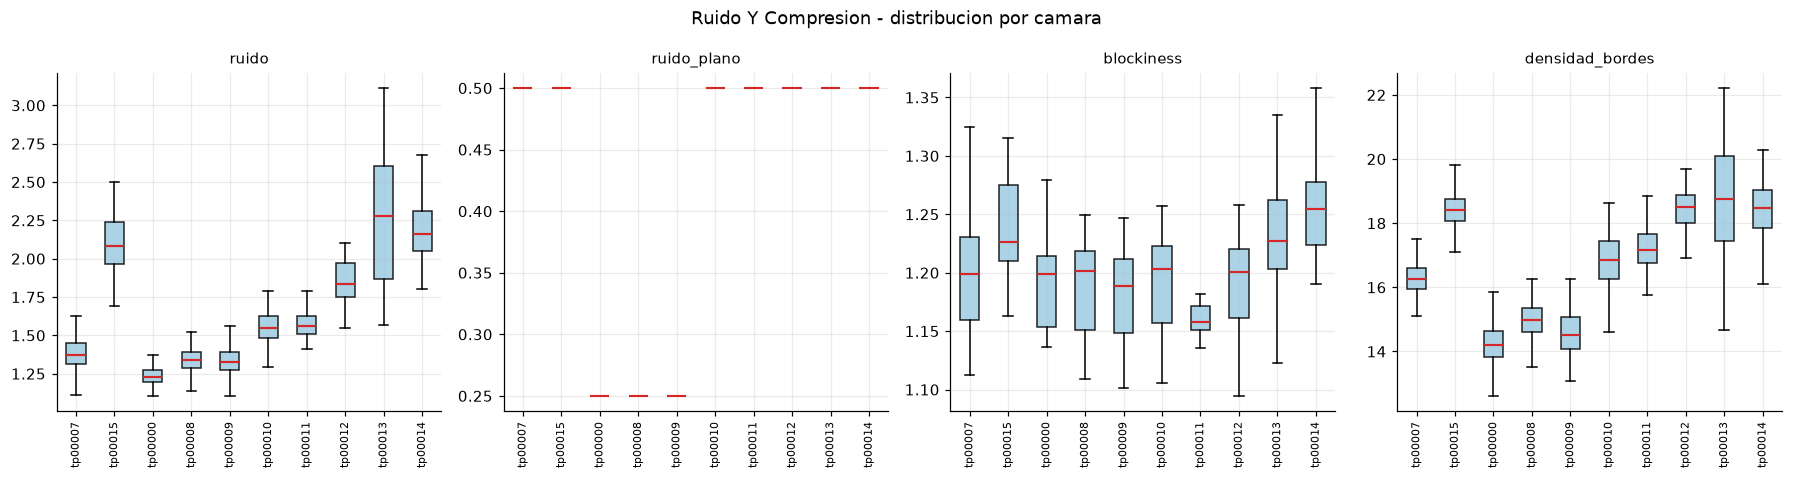

In [26]:
GRUPOS = {
    "brillo_y_exposicion": ["brillo_media", "exposicion", "pct_oscuros", "pct_claros"],
    "contraste_y_nitidez": ["contraste_std", "rango_dinamico", "entropia",
                            "nitidez_laplaciano", "nitidez_relativa"],
    "color": ["colorfulness", "saturacion_media", "tono_medio", "balance_blancos"],
    "ruido_y_compresion": ["ruido", "ruido_plano", "blockiness", "densidad_bordes"],
}

videos_orden = sorted(df_f["video"].unique())
etiquetas = [Path(v).stem.split("_")[-1] for v in videos_orden]

for nombre, cols in GRUPOS.items():
    fig, axes = plt.subplots(1, len(cols), figsize=(4.1 * len(cols), 4.4))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, cols):
        datos = [df_f.loc[df_f["video"] == v, col].dropna().values for v in videos_orden]
        bp = ax.boxplot(datos, tick_labels=etiquetas, showfliers=False,
                        patch_artist=True, medianprops=dict(color="#d62728", lw=1.4))
        for patch in bp["boxes"]:
            patch.set_facecolor("#9ecae1")
            patch.set_alpha(0.85)
        ax.set_title(col, fontsize=10)
        ax.tick_params(axis="x", rotation=90, labelsize=7)
    fig.suptitle(nombre.replace("_", " ").title() + " - distribucion por camara", fontsize=12)
    fig.tight_layout()
    fig.savefig(DIR_OUT / f"fig02_{nombre}.png", bbox_inches="tight")
    plt.show()

### Distribucion global de las variables de calidad

Los cortes verticales muestran P05, mediana y P95 de todo el dataset: dan una idea rapida de la
variabilidad y de donde estan los valores problematicos.

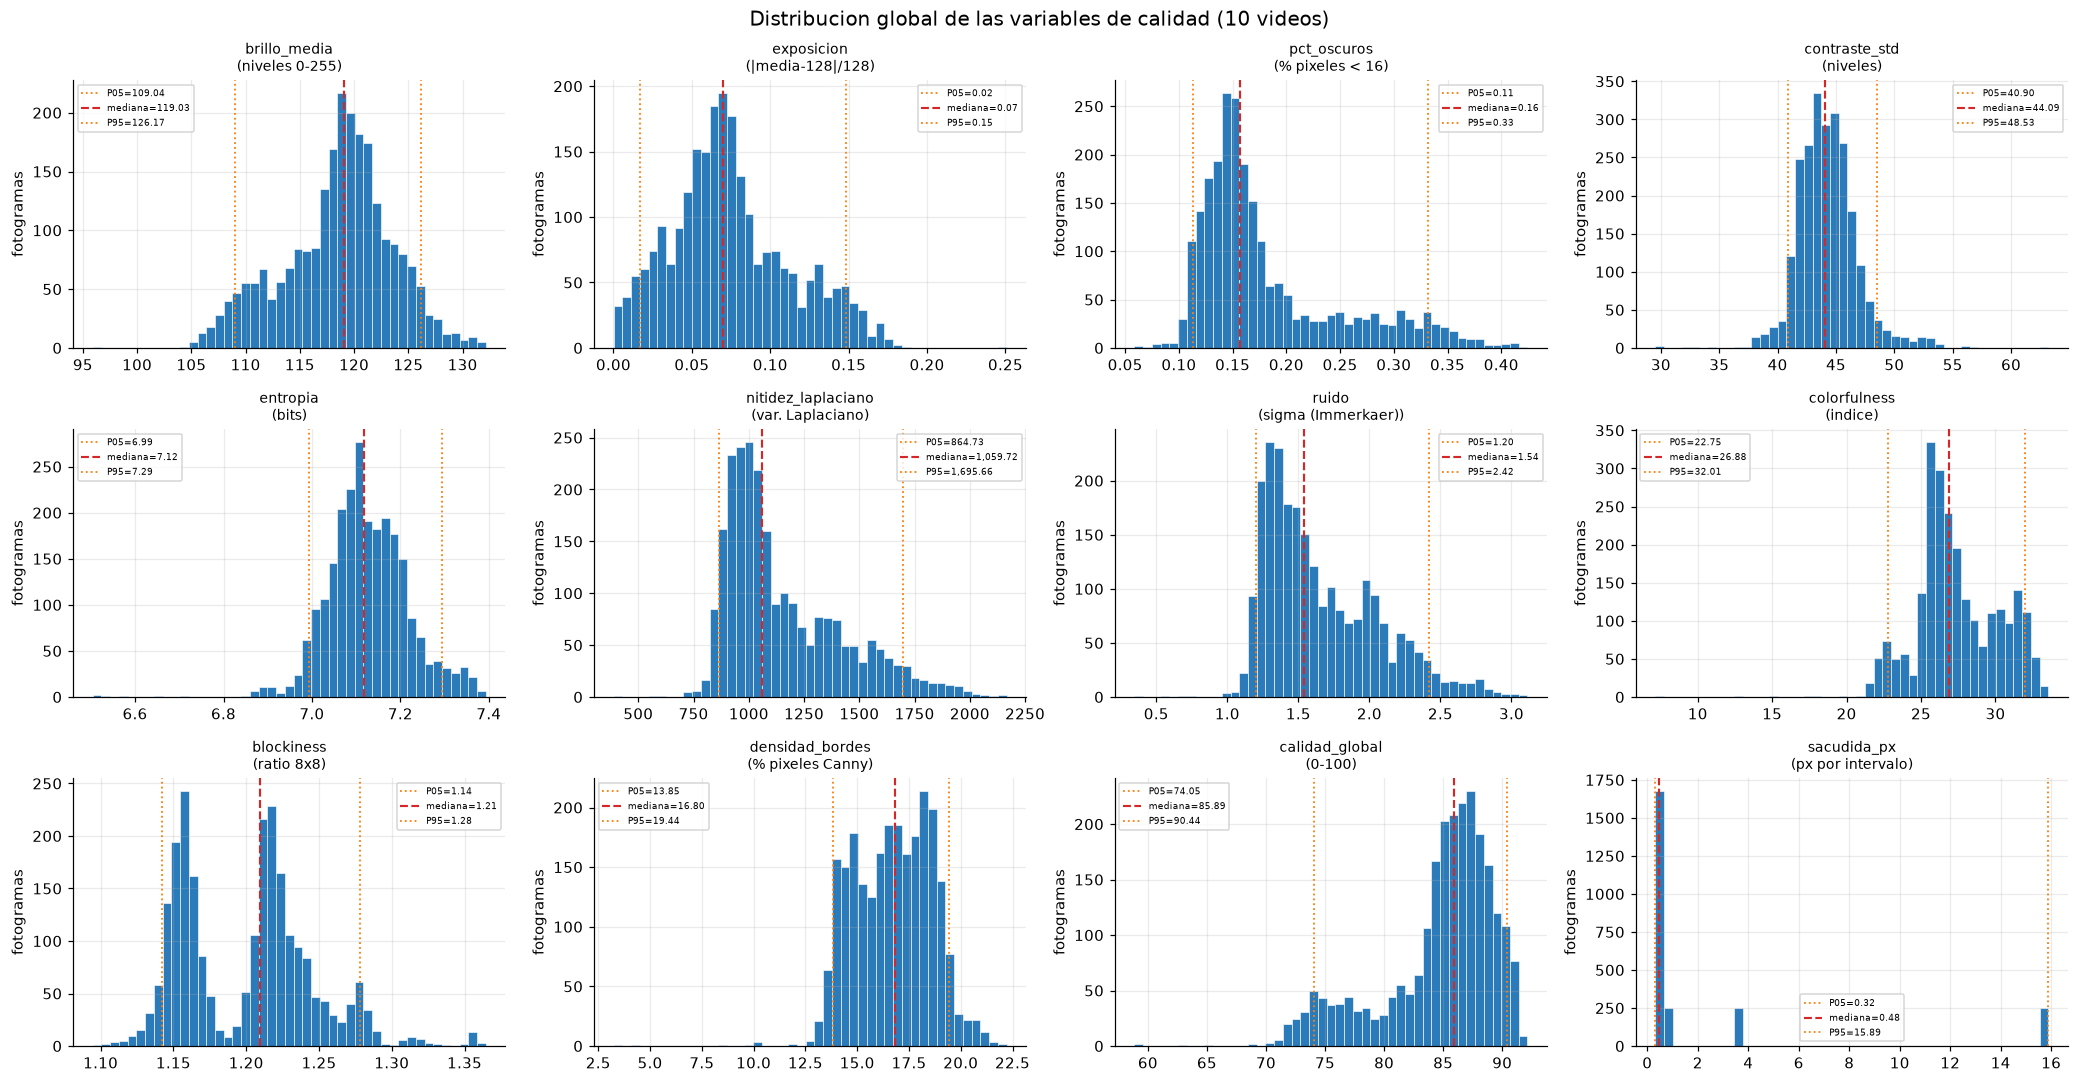

In [27]:
VARIABLES_UNIDAD = [
    ("brillo_media", "niveles 0-255"),
    ("exposicion", "|media-128|/128"),
    ("pct_oscuros", "% pixeles < 16"),
    ("contraste_std", "niveles"),
    ("entropia", "bits"),
    ("nitidez_laplaciano", "var. Laplaciano"),
    ("ruido", "sigma (Immerkaer)"),
    ("colorfulness", "indice"),
    ("blockiness", "ratio 8x8"),
    ("densidad_bordes", "% pixeles Canny"),
    ("calidad_global", "0-100"),
    ("sacudida_px", "px por intervalo"),
]

fig, axes = plt.subplots(3, 4, figsize=(19, 10))
for ax, (var, uni) in zip(axes.ravel(), VARIABLES_UNIDAD):
    serie = df_f[var].dropna()
    ax.hist(serie, bins=45, color="#2b7bba", edgecolor="white", linewidth=0.4)
    ax.axvline(serie.quantile(0.05), color="#ff7f0e", ls=":", lw=1.2,
               label=f"P05={serie.quantile(0.05):,.2f}")
    ax.axvline(serie.median(), color="#d62728", ls="--", lw=1.4,
               label=f"mediana={serie.median():,.2f}")
    ax.axvline(serie.quantile(0.95), color="#ff7f0e", ls=":", lw=1.2,
               label=f"P95={serie.quantile(0.95):,.2f}")
    ax.set_title(f"{var}\n({uni})", fontsize=9)
    ax.set_ylabel("fotogramas")
    ax.legend(fontsize=6)

fig.suptitle("Distribucion global de las variables de calidad (10 videos)", fontsize=13)
fig.tight_layout()
fig.savefig(DIR_OUT / "fig03_distribuciones_globales.png", bbox_inches="tight")
plt.show()

In [28]:
num = df_f.select_dtypes("number")
descriptivas = pd.DataFrame({
    "n": num.count(),
    "media": num.mean(),
    "mediana": num.median(),
    "std": num.std(),
    "min": num.min(),
    "P05": num.quantile(0.05),
    "P95": num.quantile(0.95),
    "max": num.max(),
    "nulos": num.isna().sum(),
    "cv_pct": (100 * num.std() / num.mean().replace(0, np.nan)).round(2),
})
descriptivas

,n,media,mediana,std,min,P05,P95,max,nulos,cv_pct
idx,2430,"9,161.451","9,075.000","5,383.867",0.000,900.000,"17,775.000","18,750.000",0,58.770
t_seg,2430,610.752,604.987,358.918,0.000,59.997,"1,184.975","1,250.107",0,58.770
minuto,2430,10.179,10.083,5.982,0.000,1.000,19.750,20.835,0,58.770
ancho,2430,"1,920.000","1,920.000",0.000,"1,920.000","1,920.000","1,920.000","1,920.000",0,0.000
alto,2430,"1,080.000","1,080.000",0.000,"1,080.000","1,080.000","1,080.000","1,080.000",0,0.000
brillo_media,2430,118.499,119.031,5.058,95.909,109.043,126.169,132.130,0,4.270
brillo_mediana,2430,107.584,108.000,5.475,71.000,97.000,115.000,124.000,0,5.090
brillo_std,2430,44.273,44.095,2.552,29.526,40.905,48.529,63.191,0,5.760
brillo_p05,2430,67.235,67.000,7.265,35.000,53.000,79.000,90.000,0,10.810
brillo_p25,2430,86.326,87.000,6.493,51.000,75.000,96.000,108.000,0,7.520


## 10. Series temporales

Evolucion de las variables a lo largo del tiempo. En una granja la iluminacion, la temperatura de
color y el nivel de actividad dependen del ciclo dia/noche y del comportamiento de las gallinas.
Los recuadros grises marcan las ventanas del barrido denso.

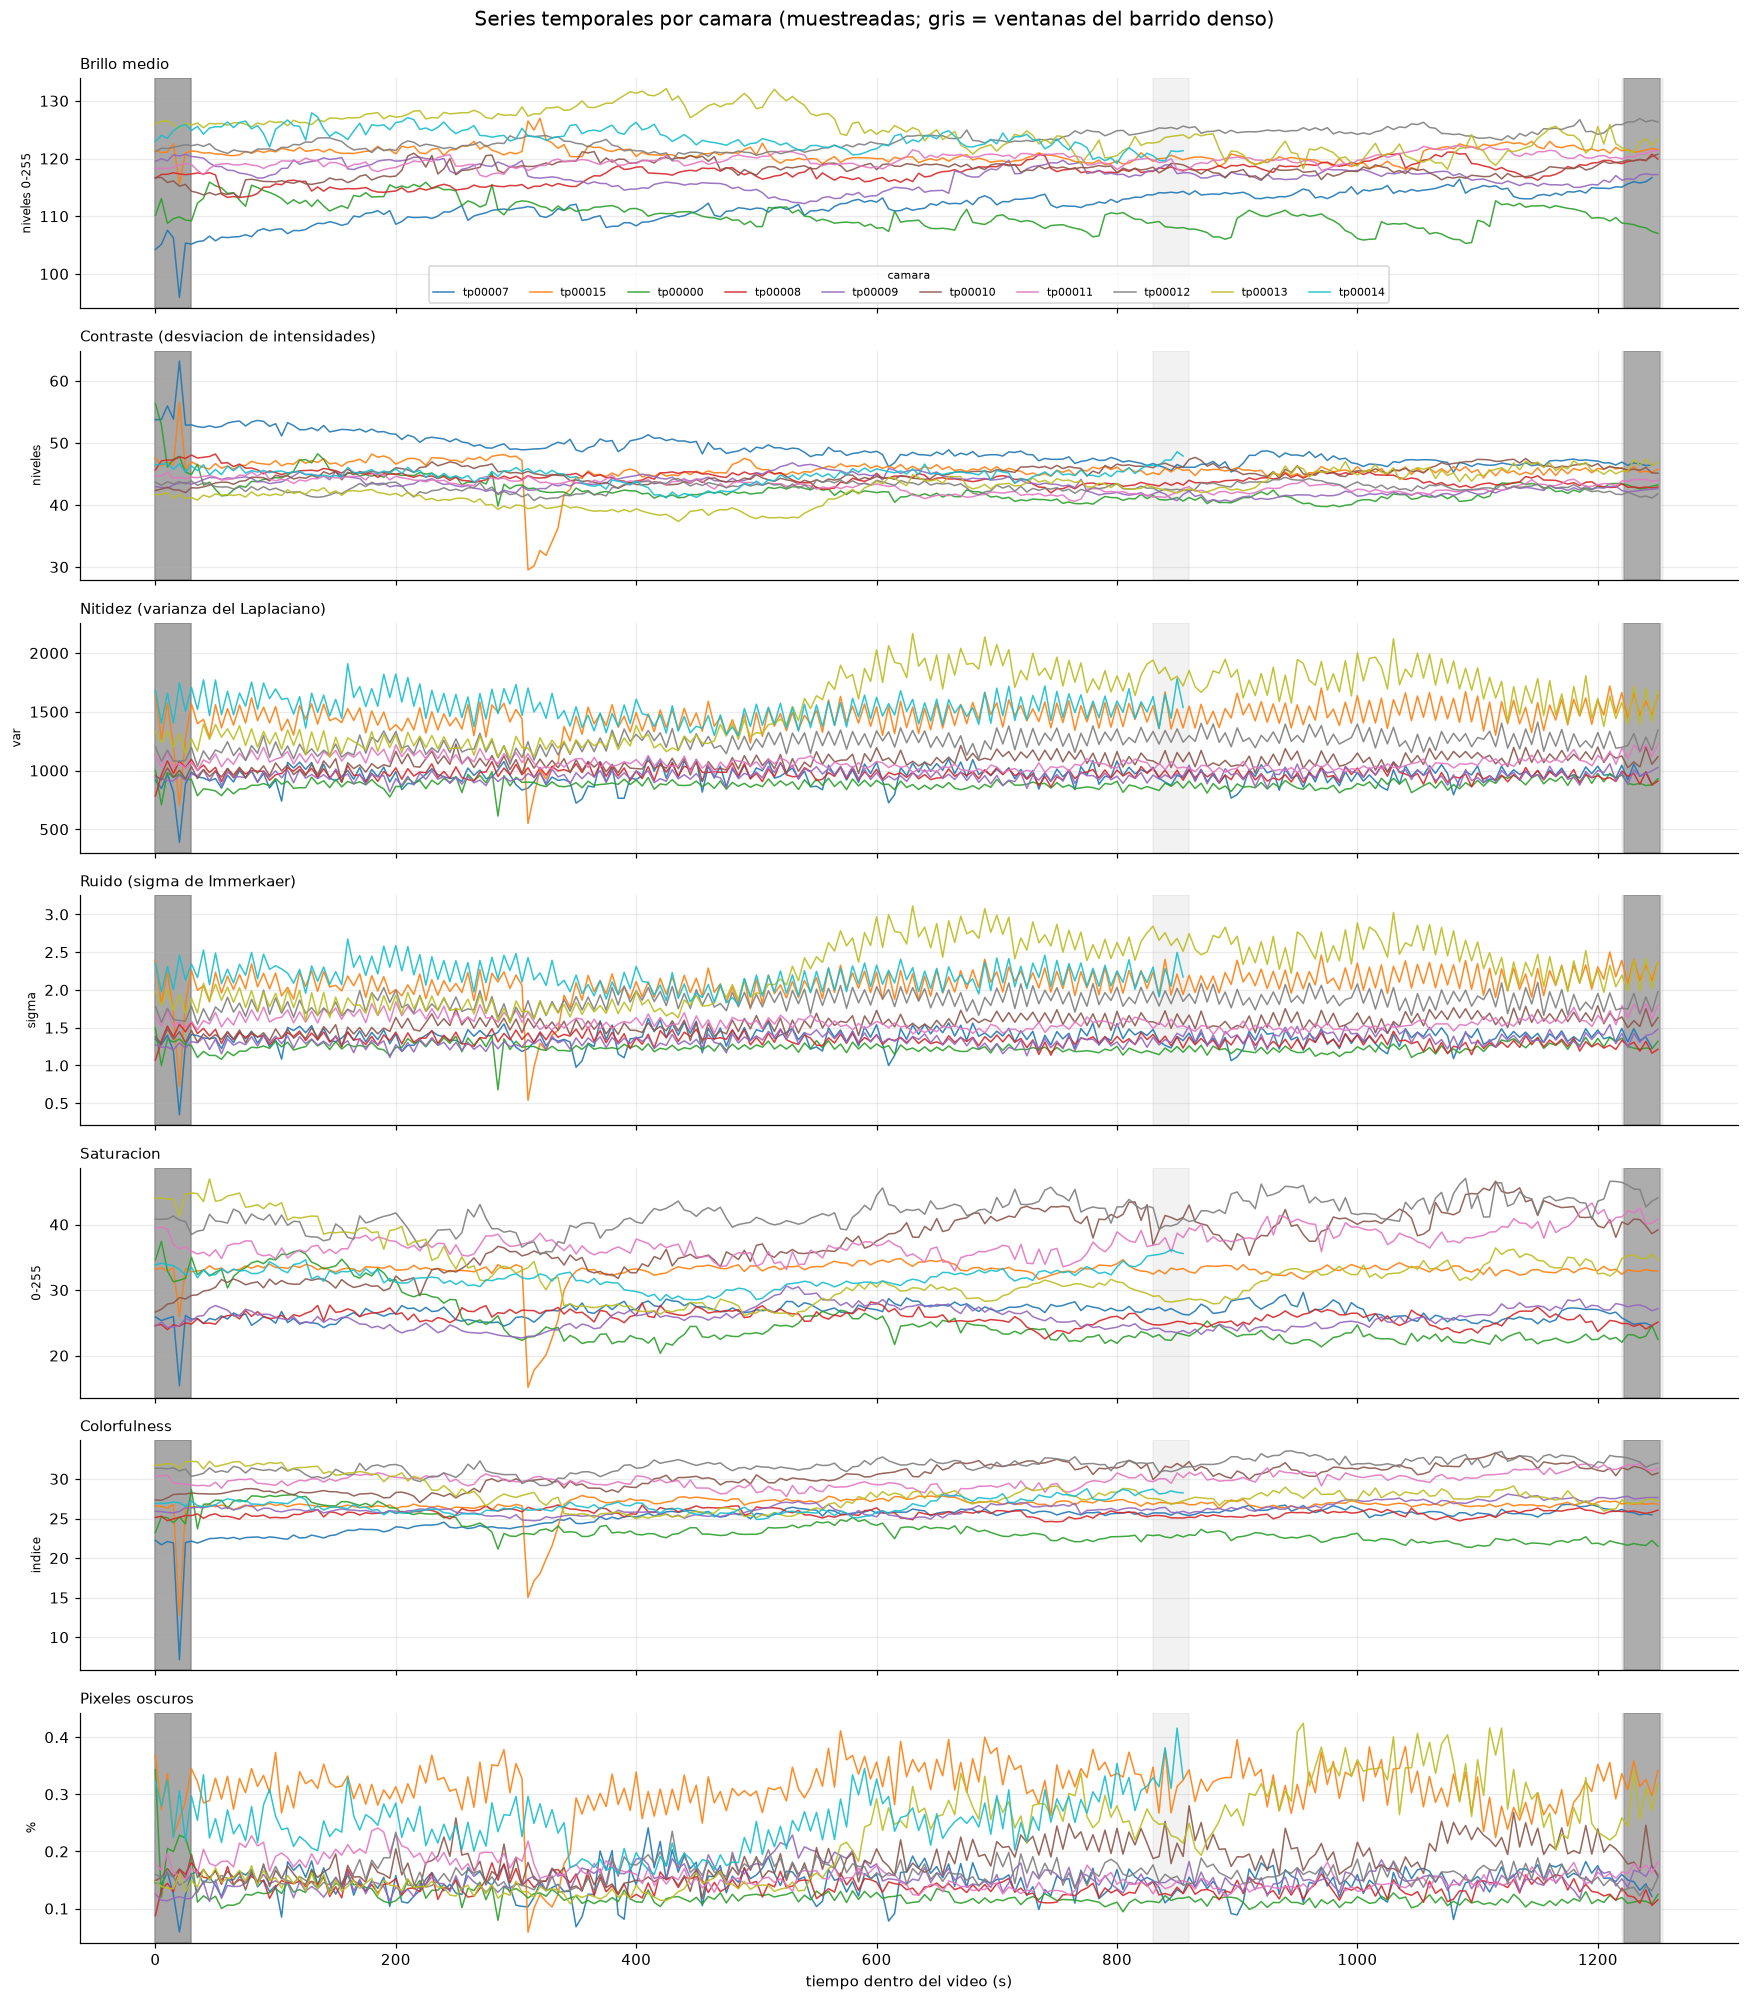

In [29]:
SERIES = [
    ("brillo_media", "Brillo medio", "niveles 0-255"),
    ("contraste_std", "Contraste (desviacion de intensidades)", "niveles"),
    ("nitidez_laplaciano", "Nitidez (varianza del Laplaciano)", "var"),
    ("ruido", "Ruido (sigma de Immerkaer)", "sigma"),
    ("saturacion_media", "Saturacion", "0-255"),
    ("colorfulness", "Colorfulness", "indice"),
    ("pct_oscuros", "Pixeles oscuros", "%"),
]

fig, axes = plt.subplots(len(SERIES), 1, figsize=(16, 2.6 * len(SERIES)), sharex=True)
for ax, (var, titulo, uni) in zip(axes, SERIES):
    for video, g in df_f.groupby("video"):
        g = g.sort_values("t_seg")
        ax.plot(g["t_seg"], g[var], lw=1.0, alpha=0.9,
                label=Path(video).stem.split("_")[-1])
    if len(df_d):
        for (video, g) in df_d.groupby("video"):
            for _, w in g.groupby("ventana"):
                ax.axvspan(w["t_seg"].min(), w["t_seg"].max(), color="grey", alpha=0.10)
    ax.set_ylabel(uni, fontsize=8)
    ax.set_title(titulo, fontsize=10, loc="left")
axes[-1].set_xlabel("tiempo dentro del video (s)")
axes[0].legend(ncol=10, fontsize=7, title="camara", title_fontsize=7)
fig.suptitle("Series temporales por camara (muestreadas; gris = ventanas del barrido denso)",
             fontsize=13, y=0.997)
fig.tight_layout()
fig.savefig(DIR_OUT / "fig04_series_temporales.png", bbox_inches="tight")
plt.show()

## 11. Movimiento y estabilidad de camara

Dos graficos clave para separar el movimiento de las gallinas del movimiento de la camara:

- **`flujo_coherencia`**: alta = la escena se mueve como un todo (camara); baja = movimiento local.
- **`desplaz_px`**: desplazamiento global entre muestras; su dispersion es la *sacudida*.

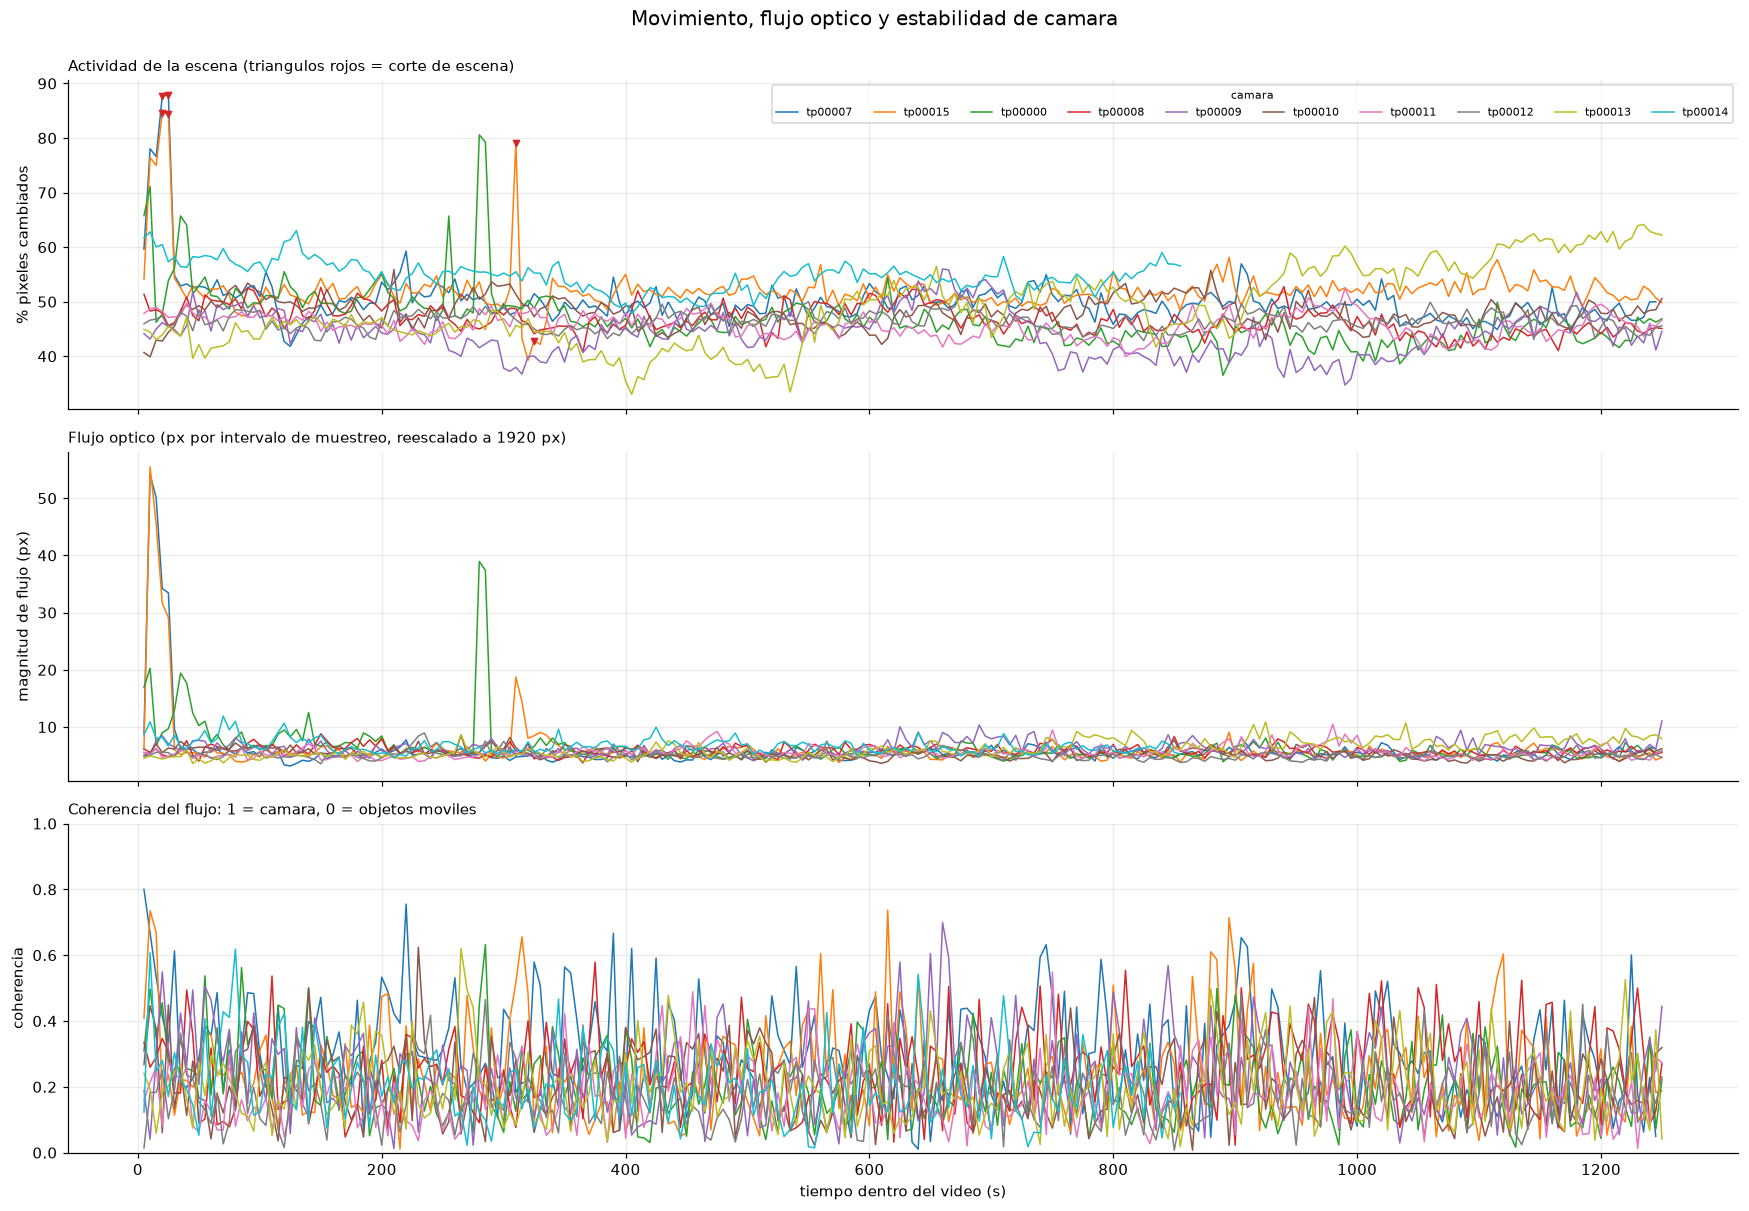

In [30]:
if len(df_t):
    fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
    for video, g in df_t.groupby("video"):
        g = g.sort_values("t_seg")
        etq = Path(video).stem.split("_")[-1]
        axes[0].plot(g["t_seg"], g["pct_cambiados"], lw=1, label=etq)
        axes[1].plot(g["t_seg"], g["flujo_mag_media"], lw=1, label=etq)
        axes[2].plot(g["t_seg"], g["flujo_coherencia"], lw=1, label=etq)

    cortes = df_t[df_t["corte_escena"]]
    for video, g in cortes.groupby("video"):
        axes[0].scatter(g["t_seg"], g["pct_cambiados"], s=16, marker="v",
                        color="#d62728", zorder=5)

    axes[0].set_ylabel("% pixeles cambiados")
    axes[0].set_title("Actividad de la escena (triangulos rojos = corte de escena)",
                      loc="left", fontsize=10)
    axes[1].set_ylabel("magnitud de flujo (px)")
    axes[1].set_title("Flujo optico (px por intervalo de muestreo, reescalado a 1920 px)",
                      loc="left", fontsize=10)
    axes[2].set_ylabel("coherencia")
    axes[2].set_ylim(0, 1)
    axes[2].set_title("Coherencia del flujo: 1 = camara, 0 = objetos moviles",
                      loc="left", fontsize=10)
    axes[2].set_xlabel("tiempo dentro del video (s)")
    axes[0].legend(ncol=10, fontsize=7, title="camara", title_fontsize=7)
    fig.suptitle("Movimiento, flujo optico y estabilidad de camara", fontsize=13, y=0.997)
    fig.tight_layout()
    fig.savefig(DIR_OUT / "fig05_movimiento.png", bbox_inches="tight")
    plt.show()

    diagnostico = (df_t.groupby("video")
                   .agg(pct_cambiados_p50=("pct_cambiados", "median"),
                        flujo_p50=("flujo_mag_media", "median"),
                        coherencia_p50=("flujo_coherencia", "median"),
                        sacudida_px_p90=("desplaz_px", lambda s: s.quantile(0.90)),
                        rotacion_max=("camara_rotacion", lambda s: s.abs().max()),
                        pct_mov_global=("camara_es_global", lambda s: 100 * s.mean()),
                        cortes=("corte_escena", "sum"),
                        congelados=("congelado", "sum"),
                        duplicados=("duplicado", "sum"))
                   .round(3)
                   .assign(camara=lambda d: [Path(v).stem.split("_")[-1] for v in d.index])
                   .reset_index()
                   .drop(columns="video"))
    diagnostico

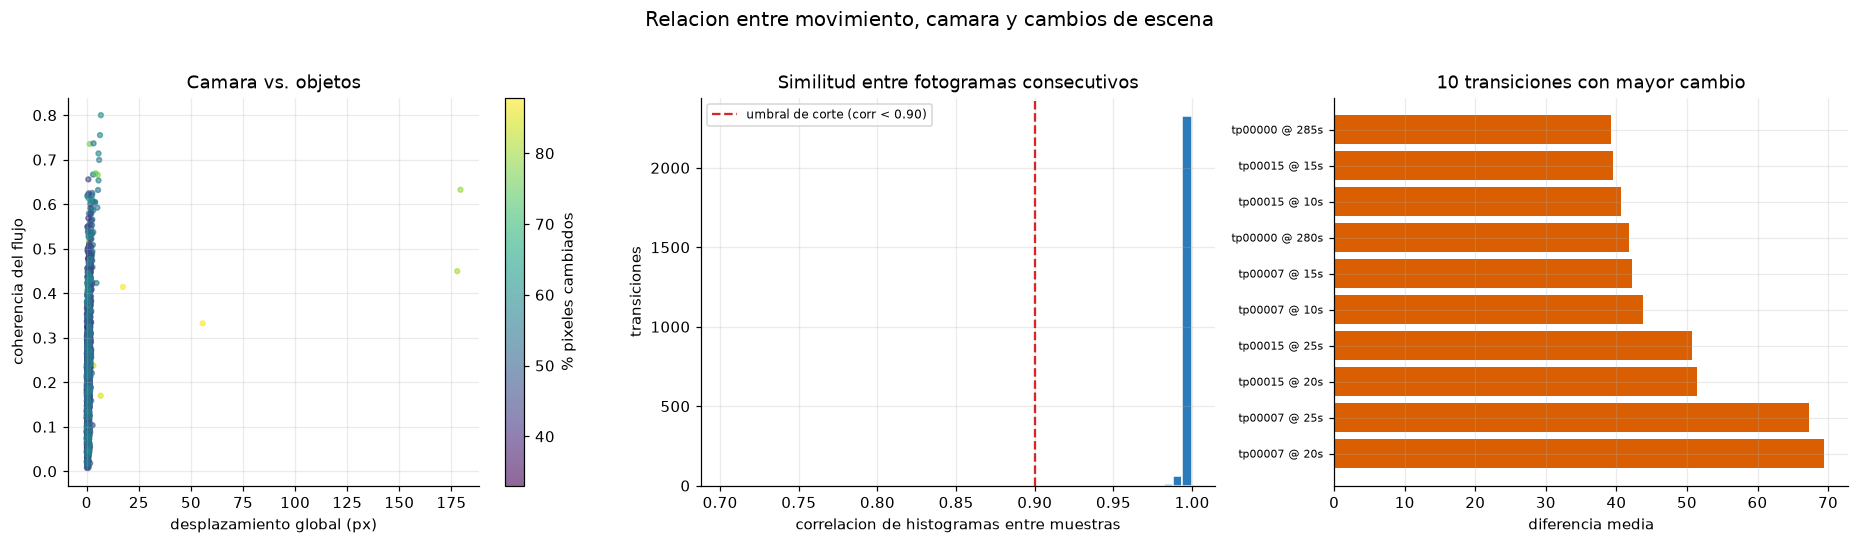

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

if len(df_t):
    sc = axes[0].scatter(df_t["desplaz_px"], df_t["flujo_coherencia"],
                         c=df_t["pct_cambiados"], cmap="viridis", s=10, alpha=0.6)
    axes[0].set_xlabel("desplazamiento global (px)")
    axes[0].set_ylabel("coherencia del flujo")
    axes[0].set_title("Camara vs. objetos")
    plt.colorbar(sc, ax=axes[0], label="% pixeles cambiados")

    axes[1].hist(df_t["hist_correl"], bins=50, color="#2b7bba", edgecolor="white")
    axes[1].axvline(1 - UMBRAL_CORTE_ESCENA, color="#d62728", ls="--",
                    label=f"umbral de corte (corr < {1 - UMBRAL_CORTE_ESCENA:.2f})")
    axes[1].set_xlabel("correlacion de histogramas entre muestras")
    axes[1].set_ylabel("transiciones")
    axes[1].set_title("Similitud entre fotogramas consecutivos")
    axes[1].legend(fontsize=8)

    top = (df_t.nlargest(10, "diff_media")
           .assign(camara=lambda d: [Path(v).stem.split("_")[-1] for v in d["video"]]))
    axes[2].barh([f"{r.camara} @ {r.t_seg:.0f}s" for r in top.itertuples()],
                 top["diff_media"], color="#d95f02")
    axes[2].set_xlabel("diferencia media")
    axes[2].set_title("10 transiciones con mayor cambio")
    axes[2].tick_params(axis="y", labelsize=7)

fig.suptitle("Relacion entre movimiento, camara y cambios de escena", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(DIR_OUT / "fig06_cortes_y_similitud.png", bbox_inches="tight")
plt.show()

## 12. Continuidad de la grabacion

Fotogramas negros, congelamientos y *stalls* (grabacion detenida).

El **barrido denso** (`df_d`) lee a FPS nativo dentro de ventanas cortas: es la unica forma fiable de
detectar una perdida de grabacion de 1 a 3 segundos, que el muestreo cada 5 s puede saltarse.

Un detalle importante de la calibracion: en una escena estatica a 15 fps, **el 54% de los pares de
fotogramas consecutivos tienen un dHash identico** (distancia de Hamming 0) y el 97% estan a distancia
<= 2. Por eso "fotograma repetido" no es un problema en si mismo: lo que delata un fallo es una
**racha larga** de fotogramas identicos. Por eso aqui se mide `racha_identicos` y se marca
`es_stall` cuando la racha supera `UMBRAL_RACHA_STALL` fotogramas.

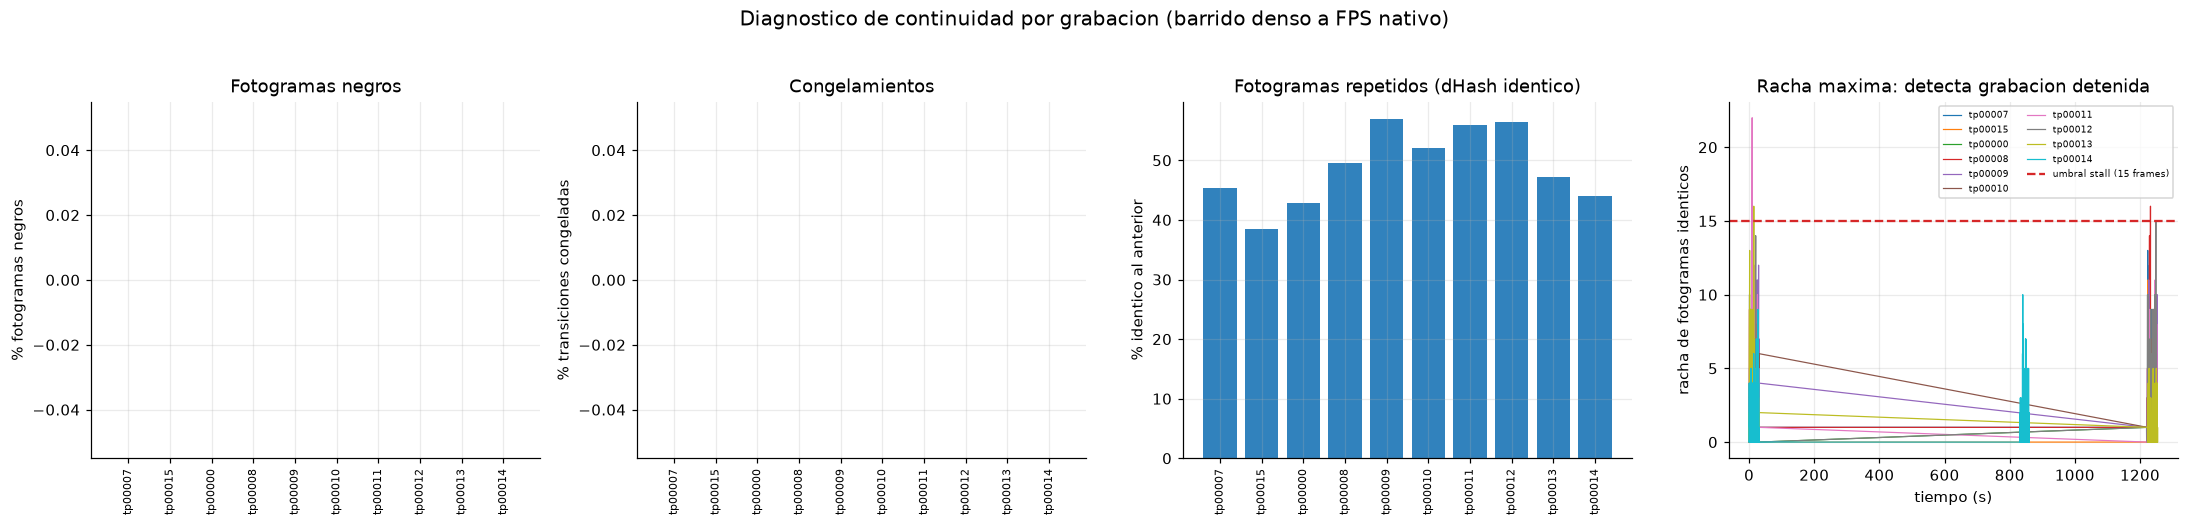

In [32]:
if len(df_d):
    por_video = [(Path(v).stem.split("_")[-1], g) for v, g in df_d.groupby("video")]
    etiquetas_d = [c for c, _ in por_video]

    fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))

    axes[0].bar(etiquetas_d, [100 * g["negro"].mean() for _, g in por_video], color="#636363")
    axes[0].set_ylabel("% fotogramas negros")
    axes[0].set_title("Fotogramas negros")

    axes[1].bar(etiquetas_d, [100 * g["congelado"].mean() for _, g in por_video],
                color="#e6550d")
    axes[1].set_ylabel("% transiciones congeladas")
    axes[1].set_title("Congelamientos")

    axes[2].bar(etiquetas_d, [100 * g["identico"].mean() for _, g in por_video],
                color="#3182bd")
    axes[2].set_ylabel("% identico al anterior")
    axes[2].set_title("Fotogramas repetidos (dHash identico)")

    for etq, g in por_video:
        axes[3].plot(g["t_seg"], g["racha_identicos"], lw=0.8, label=etq)
    axes[3].axhline(UMBRAL_RACHA_STALL, color="#d62728", ls="--",
                    label=f"umbral stall ({UMBRAL_RACHA_STALL} frames)")
    axes[3].set_xlabel("tiempo (s)")
    axes[3].set_ylabel("racha de fotogramas identicos")
    axes[3].set_title("Racha maxima: detecta grabacion detenida")
    axes[3].legend(fontsize=6, ncol=2)

    for ax in axes[:3]:
        ax.tick_params(axis="x", rotation=90, labelsize=7)
    fig.suptitle("Diagnostico de continuidad por grabacion (barrido denso a FPS nativo)",
                 fontsize=13, y=1.03)
    fig.tight_layout()
    fig.savefig(DIR_OUT / "fig07_continuidad.png", bbox_inches="tight")
    plt.show()

    tabla_continuidad = (df_d.groupby("video")
                         .agg(idx_densos=("dif_media", "size"),
                              negros=("negro", "sum"),
                              pct_negros=("negro", lambda s: 100 * s.mean()),
                              congelados=("congelado", "sum"),
                              pct_congelados=("congelado", lambda s: 100 * s.mean()),
                              pct_identicos=("identico", lambda s: 100 * s.mean()),
                              racha_max=("racha_identicos", "max"),
                              stalls=("es_stall", "sum"),
                              dif_p50=("dif_media", "median"))
                         .round(3)
                         .reset_index())
    tabla_continuidad

## 13. Cambios de escena y redundancia

Dos objetivos: **segmentar** cada grabacion en tramos visualmente distintos y **evitar frames
redundantes** al construir el conjunto de etiquetado.

El corte de escena se evalua con dos criterios, porque ninguno es suficiente por si solo:

- **Umbral fijo** (`UMBRAL_CORTE_ESCENA`): interpretable, pero depende de la iluminacion de cada
  grabacion.
- **Umbral adaptativo** (`mediana + K_MAD_CORTE * sigma robusta`): se calcula dentro de cada video,
  por lo que funciona aunque un video sea mucho mas luminoso que otro. Es el criterio recomendado.

Distribucion de la distancia entre fotogramas consecutivos (1 - correlacion):
  P50     : 0.0017
  P75     : 0.0026
  P90     : 0.0041
  P95     : 0.0056
  P99     : 0.0145
  maximo  : 0.2972

Sensibilidad del umbral fijo de corte:
  0.02 ->   20 cortes (0.8% de las transiciones)
  0.05 ->   10 cortes (0.4% de las transiciones)
  0.10 ->    6 cortes (0.2% de las transiciones)
  0.20 ->    5 cortes (0.2% de las transiciones)
  0.40 ->    0 cortes (0.0% de las transiciones)

Comparacion de criterios sobre 2,420 transiciones:


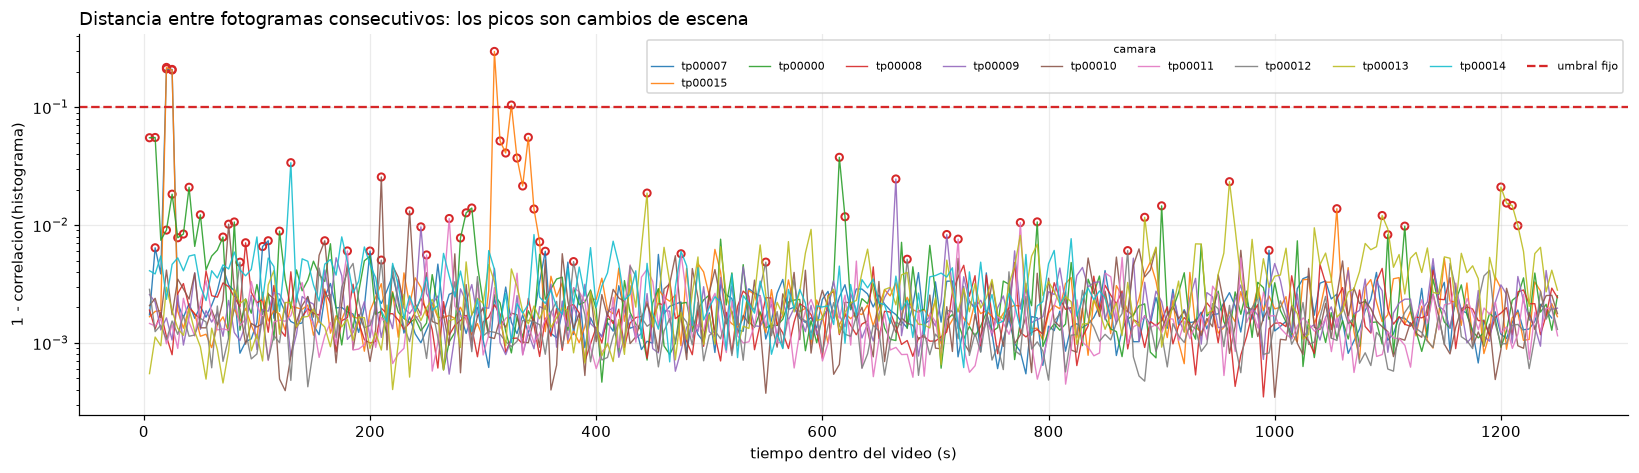

In [33]:
if len(df_t):
    dist = (1 - df_t["hist_correl"]).to_numpy()
    print("Distribucion de la distancia entre fotogramas consecutivos (1 - correlacion):")
    for nombre, valor in zip(["P50", "P75", "P90", "P95", "P99", "maximo"],
                             [*np.quantile(dist, [0.50, 0.75, 0.90, 0.95, 0.99]), dist.max()]):
        print(f"  {nombre:8s}: {valor:.4f}")

    print("\nSensibilidad del umbral fijo de corte:")
    for u in [0.02, 0.05, 0.10, 0.20, 0.40]:
        print(f"  {u:.2f} -> {int((dist > u).sum()):4d} cortes "
              f"({100 * (dist > u).mean():.1f}% de las transiciones)")

    print(f"\nComparacion de criterios sobre {len(df_t):,} transiciones:")
    comparativa_cortes = pd.DataFrame({
        "criterio": ["umbral fijo (UMBRAL_CORTE_ESCENA)",
                     f"adaptativo (mediana + {K_MAD_CORTE} sigma robusta)",
                     "z robusto > 6"],
        "cortes": [int(df_t["corte_escena"].sum()),
                   int(df_t["corte_escena_adaptivo"].sum()),
                   int((df_t["z_robusto_hist"] > 6).sum())],
    })
    comparativa_cortes

    fig, ax = plt.subplots(figsize=(15, 4.4))
    for video, g in df_t.groupby("video"):
        g = g.sort_values("t_seg")
        ax.plot(g["t_seg"], 1 - g["hist_correl"], lw=0.9, alpha=0.9,
                label=Path(video).stem.split("_")[-1])
    ax.axhline(UMBRAL_CORTE_ESCENA, color="#d62728", ls="--", label="umbral fijo")
    for video, g in df_t[df_t["corte_escena_adaptivo"]].groupby("video"):
        ax.scatter(g["t_seg"], 1 - g["hist_correl"], s=22, marker="o",
                   facecolors="none", edgecolors="#d62728", linewidths=1.3)
    ax.set_yscale("log")
    ax.set_xlabel("tiempo dentro del video (s)")
    ax.set_ylabel("1 - correlacion(histograma)")
    ax.set_title("Distancia entre fotogramas consecutivos: los picos son cambios de escena",
                 loc="left")
    ax.legend(ncol=10, fontsize=7, title="camara", title_fontsize=7)
    fig.tight_layout()
    fig.savefig(DIR_OUT / "fig08_cortes_escena.png", bbox_inches="tight")
    plt.show()

In [34]:
def agrupar_duplicados(hashes, umbral=UMBRAL_DUPLICADO_HAMMING):
    '''Agrupa hashes perceptualmente iguales (distancia de Hamming <= umbral).

    Union-find: O(n^2) comparaciones, aceptable para los ~2500 fotogramas muestreados.
    '''
    parent = list(range(len(hashes)))

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    ints = [int(h, 16) for h in hashes]
    for i in range(len(ints)):
        for j in range(i + 1, len(ints)):
            if bin(ints[i] ^ ints[j]).count("1") <= umbral:
                ri, rj = find(i), find(j)
                if ri != rj:
                    parent[rj] = ri

    grupos = {}
    for i in range(len(ints)):
        grupos.setdefault(find(i), []).append(i)
    return list(grupos.values())


grupos_dup = agrupar_duplicados(df_f["dhash"].tolist())
redundancia = (pd.Series([len(g) for g in grupos_dup])
               .value_counts().rename_axis("tamano_grupo")
               .rename("n_grupos").reset_index()
               .sort_values("tamano_grupo"))

n_unicos = len(grupos_dup)
print(f"Fotogramas muestreados   : {len(df_f):,}")
print(f"Imagenes distintas (dHash): {n_unicos:,}")
print(f"Redundancia              : {100 * (1 - n_unicos / len(df_f)):.1f} %")
print(f"Grupos con mas de 1 frame: {(redundancia['tamano_grupo'] > 1).sum():,}")
redundancia.head(10)

Fotogramas muestreados   : 2,430
Imagenes distintas (dHash): 1,053
Redundancia              : 56.7 %
Grupos con mas de 1 frame: 14


,tamano_grupo,n_grupos
0,1,889
1,2,95
2,3,30
3,4,19
4,5,7
5,6,3
6,7,2
14,8,1
9,12,1
13,13,1


In [35]:
# frecuencia de duplicados dentro de cada video
dup_por_video = (df_f.groupby("video")["dhash"]
                 .apply(lambda s: len(agrupar_duplicados(s.tolist())))
                 .rename("imagenes_distintas").to_frame())
dup_por_video["muestreadas"] = df_f.groupby("video").size()
dup_por_video["redundancia_pct"] = (100 * (1 - dup_por_video["imagenes_distintas"]
                                           / dup_por_video["muestreadas"])).round(1)
dup_por_video["recomendado_muestreo_s"] = (MUESTREO_SEGUNDOS
                                          * dup_por_video["redundancia_pct"].clip(lower=10) / 100
                                          ).round(1)
dup_por_video

,imagenes_distintas,muestreadas,redundancia_pct,recomendado_muestreo_s
video,,,,
20240805_215845_tp00007.mp4,128,250,48.800,2.400
20240805_215845_tp00015.mp4,84,251,66.500,3.300
20260727_173621_tp00000.mp4,154,251,38.600,1.900
20260728_064628_tp00008.mp4,106,251,57.800,2.900
20260728_070720_tp00009.mp4,104,251,58.600,2.900
20260728_072812_tp00010.mp4,120,251,52.200,2.600
20260728_074904_tp00011.mp4,115,251,54.200,2.700
20260728_080956_tp00012.mp4,88,251,64.900,3.200
20260728_083048_tp00013.mp4,138,251,45.000,2.200


### Fotogramas candidatos para etiquetar

In [36]:
def mejor_por_video(df, n=1):
    '''Los n fotogramas de mayor calidad global por video.'''
    return (df.sort_values("calidad_global", ascending=False)
              .groupby("video").head(n)
              .sort_values(["video", "calidad_global"], ascending=[True, False])
              .reset_index(drop=True))


mejores = mejor_por_video(df_f, n=1)
candidatos = mejores[["video", "camara", "idx", "t_seg", "minuto", "calidad_global",
                     "brillo_media", "contraste_std", "nitidez_laplaciano",
                     "colorfulness", "nivel_luz", "nivel_movimiento"]].round(2)
candidatos

,video,camara,idx,t_seg,minuto,calidad_global,brillo_media,contraste_std,nitidez_laplaciano,colorfulness,nivel_luz,nivel_movimiento
0,20240805_215845_tp00007.mp4,tp00007,6450,429.970,7.170,85.220,110.190,50.620,"1,070.540",25.910,medio,intenso
1,20240805_215845_tp00015.mp4,tp00015,0,0.000,0.000,90.220,121.450,47.570,"1,648.500",26.580,claro,intenso
2,20260727_173621_tp00000.mp4,tp00000,0,0.000,0.000,81.090,110.140,56.330,"1,000.700",23.220,medio,moderado
3,20260728_064628_tp00008.mp4,tp00008,450,30.000,0.500,89.670,117.320,48.040,"1,096.240",25.370,medio,moderado
4,20260728_070720_tp00009.mp4,tp00009,2250,150.000,2.500,89.250,119.980,45.390,"1,012.230",26.060,medio,moderado
5,20260728_072812_tp00010.mp4,tp00010,17100,"1,139.980",19.000,91.280,116.850,47.480,"1,196.590",32.480,medio,moderado
6,20260728_074904_tp00011.mp4,tp00011,18525,"1,235.110",20.580,90.870,120.790,44.080,"1,155.810",31.930,claro,moderado
7,20260728_080956_tp00012.mp4,tp00012,14100,939.980,15.670,92.140,124.680,44.460,"1,394.340",33.500,claro,moderado
8,20260728_083048_tp00013.mp4,tp00013,15225,"1,014.980",16.920,91.170,122.640,46.490,"1,964.660",28.860,claro,intenso
9,20260728_085142_tp00014.mp4,tp00014,12750,849.970,14.170,91.420,121.210,48.580,"1,781.770",28.300,claro,intenso


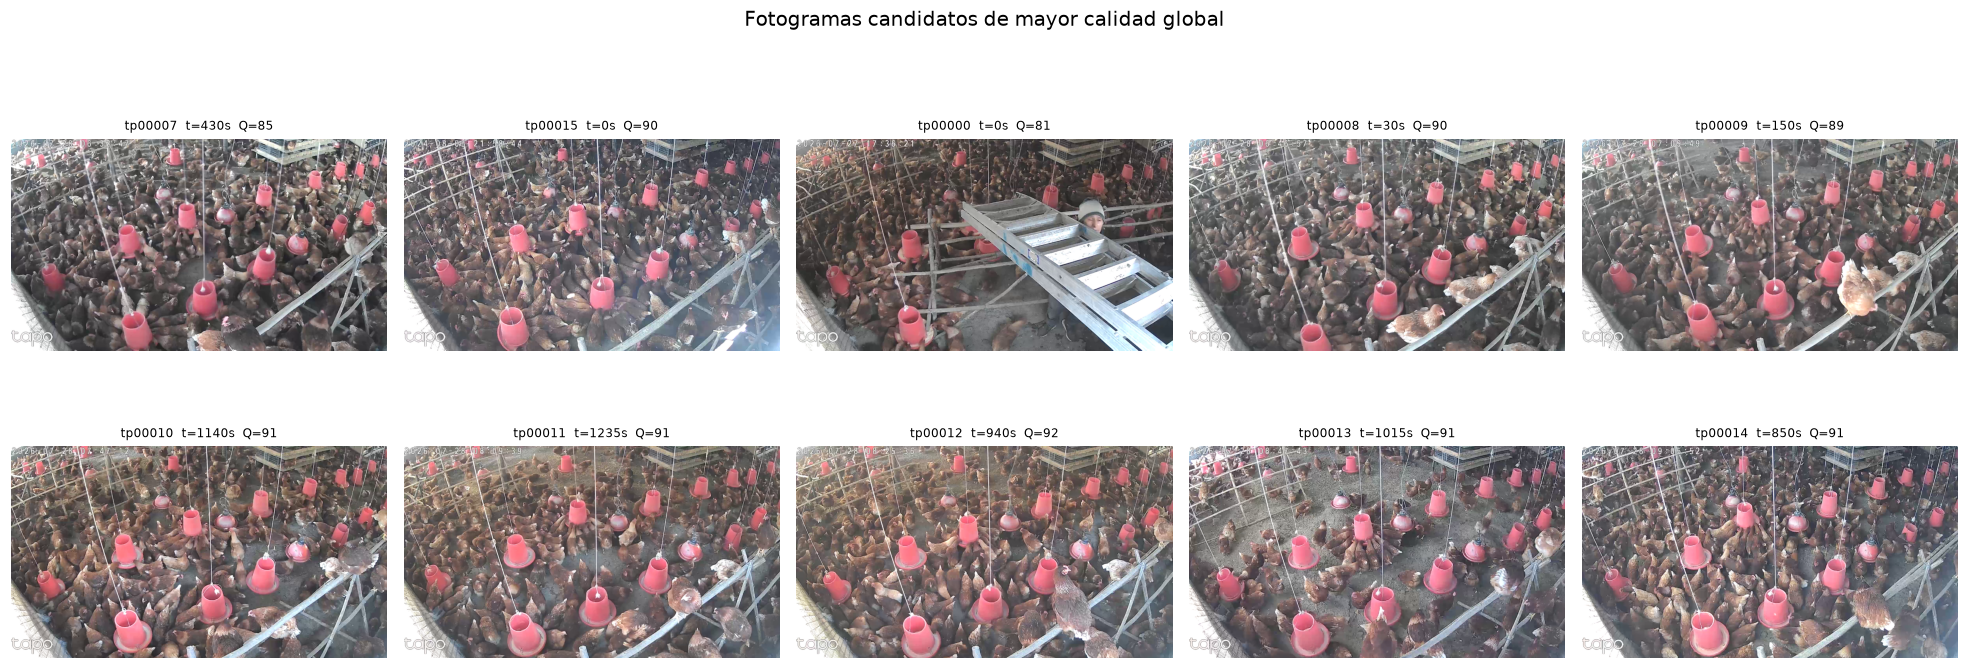

In [37]:
def miniaturas(filas, ncols=5):
    '''Monta una rejela de miniaturas a partir de fotogramas candidatos.'''
    imagenes = []
    for r in filas.itertuples():
        cap = cv2.VideoCapture(str(DIR_VIDEOS / r.video))
        ok, frame, _ = leer_fotograma(cap, int(r.idx))
        cap.release()
        if ok:
            titulo = f"{r.camara}  t={r.t_seg:.0f}s  Q={r.calidad_global:.0f}"
            imagenes.append((titulo, cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
    if not imagenes:
        print("No se pudieron leer los fotogramas.")
        return

    nfilas = int(np.ceil(len(imagenes) / ncols))
    fig, axes = plt.subplots(nfilas, ncols, figsize=(18, 3.5 * nfilas))
    for ax in np.atleast_1d(axes).ravel():
        ax.axis("off")
    for ax, (titulo, img) in zip(np.atleast_1d(axes).ravel(), imagenes):
        ax.imshow(img)
        ax.set_title(titulo, fontsize=8)
    fig.suptitle("Fotogramas candidatos de mayor calidad global", fontsize=13)
    fig.tight_layout()
    fig.savefig(DIR_OUT / "fig09_mejores_fotogramas.png", bbox_inches="tight")
    plt.show()


miniaturas(mejores)

### Seleccion diversa dentro de un video

En lugar de tomar los N fotogramas mas parecidos entre si, el *farthest point sampling* elige los que
mas se diferencian en el espacio de caracteristicas de calidad. Es la forma correcta de construir un
conjunto de etiquetado que cubra la variedad de la grabacion.

In [38]:
def seleccionar_diversos(df, n=6, cols=None):
    '''Farthest point sampling: n fotogramas visualmente distintos.'''
    cols = cols or ["brillo_media", "contraste_std", "nitidez_laplaciano",
                    "saturacion_media", "colorfulness", "dif_media_prom"]
    sub = df.dropna(subset=cols)
    X = sub[cols].astype(float).to_numpy()
    X = (X - X.mean(0)) / (X.std(0) + 1e-9)

    elegido = int(np.argmax(np.linalg.norm(X, axis=1)))
    sel = [elegido]
    dist = np.linalg.norm(X - X[elegido], axis=1)
    for _ in range(min(n, len(X)) - 1):
        elegido = int(np.argmax(dist))
        sel.append(elegido)
        dist = np.minimum(dist, np.linalg.norm(X - X[elegido], axis=1))
    return sub.iloc[sel].reset_index(drop=True)


video_demo = df_f["video"].mode().iat[0]
sel = seleccionar_diversos(df_f[df_f["video"] == video_demo], n=6)
print(f"Video: {video_demo}")
sel[["t_seg", "minuto", "brillo_media", "contraste_std", "nitidez_laplaciano",
     "saturacion_media", "colorfulness", "calidad_global"]].round(2)

Video: 20240805_215845_tp00015.mp4


,t_seg,minuto,brillo_media,contraste_std,nitidez_laplaciano,saturacion_media,colorfulness,calidad_global
0,309.980,5.170,126.520,29.530,549.900,15.160,15.040,59.330
1,"1,039.930",17.330,118.120,46.130,"1,660.990",33.720,26.860,89.150
2,20.000,0.330,115.620,56.500,706.500,25.970,12.750,69.050
3,334.980,5.580,121.770,36.310,"1,063.760",25.460,23.960,74.130
4,15.000,0.250,122.530,46.440,"1,197.470",33.400,26.760,81.280
5,324.980,5.420,123.280,31.870,927.990,20.110,19.860,68.960


## 14. Correlaciones entre variables de calidad

Detecta redundancias (por ejemplo nitidez vs. densidad de bordes) y relaciones que afectaran al
modelo (por ejemplo brillo vs. ruido).

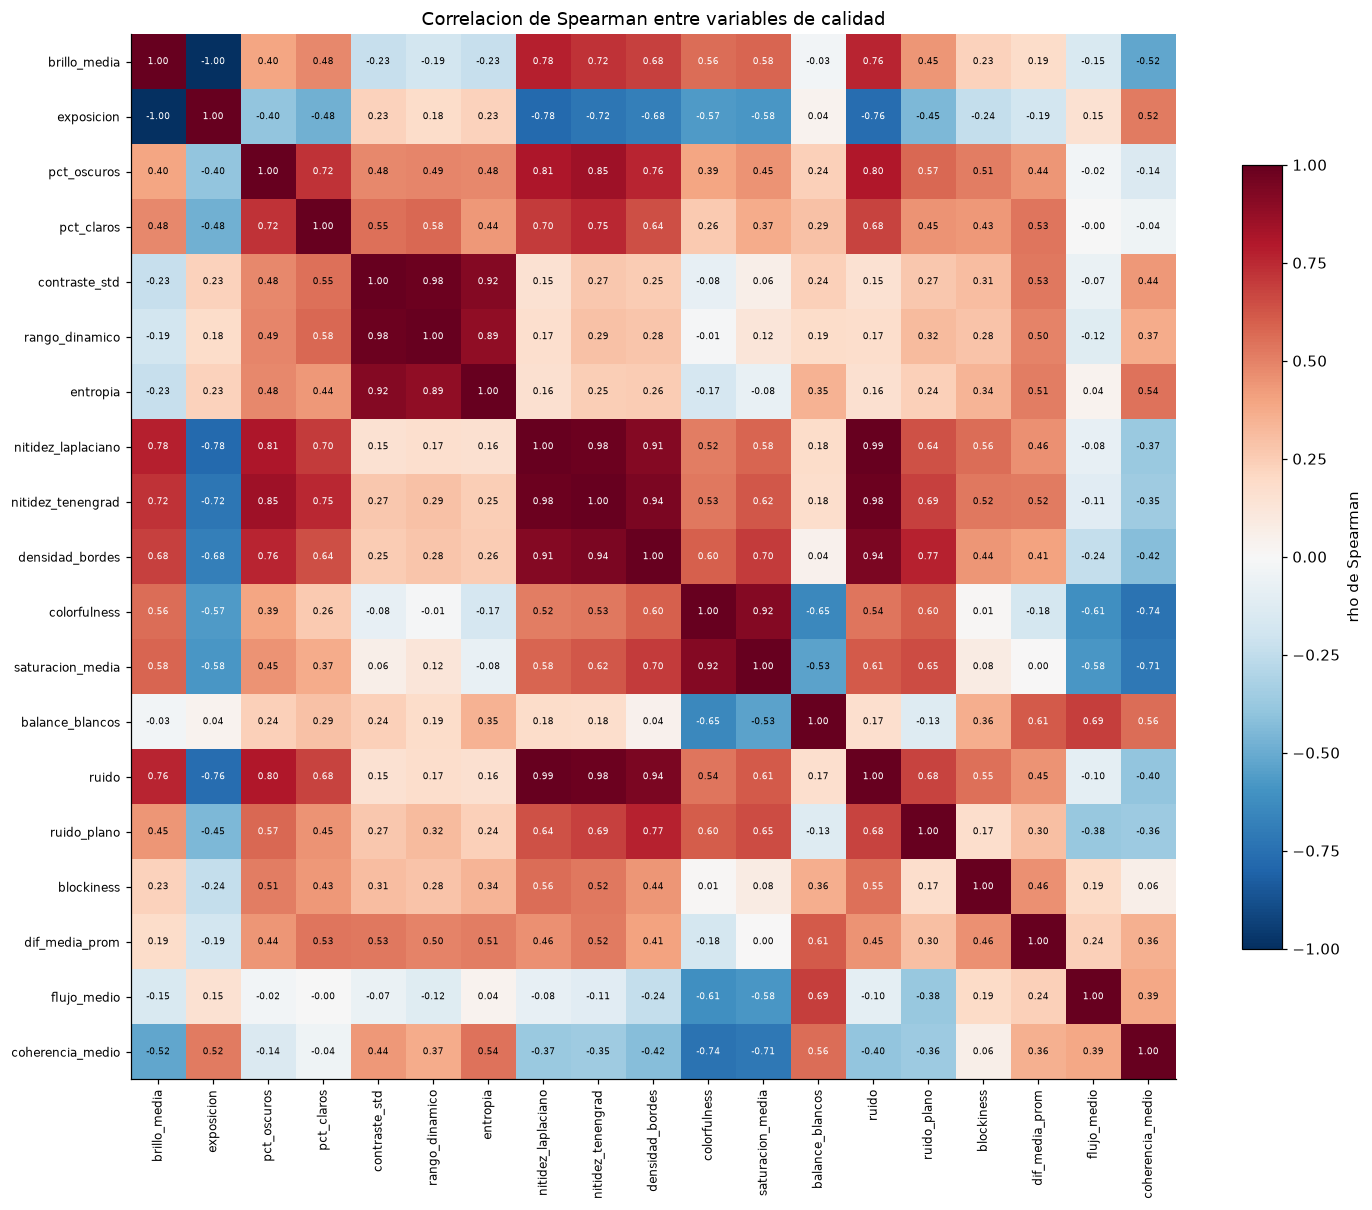

In [39]:
VARS_CORR = ["brillo_media", "exposicion", "pct_oscuros", "pct_claros",
             "contraste_std", "rango_dinamico", "entropia",
             "nitidez_laplaciano", "nitidez_tenengrad", "densidad_bordes",
             "colorfulness", "saturacion_media", "balance_blancos",
             "ruido", "ruido_plano", "blockiness",
             "dif_media_prom", "flujo_medio", "coherencia_medio"]

matriz = df_f[VARS_CORR].corr(method="spearman")

fig, ax = plt.subplots(figsize=(13.5, 11))
im = ax.imshow(matriz, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(VARS_CORR)))
ax.set_yticks(range(len(VARS_CORR)))
ax.set_xticklabels(VARS_CORR, rotation=90, fontsize=8)
ax.set_yticklabels(VARS_CORR, fontsize=8)
ax.grid(False)
for i in range(len(VARS_CORR)):
    for j in range(len(VARS_CORR)):
        v = matriz.iat[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.2,
                color="white" if abs(v) > 0.55 else "black")
plt.colorbar(im, ax=ax, shrink=0.75, label="rho de Spearman")
ax.set_title("Correlacion de Spearman entre variables de calidad", fontsize=12)
fig.tight_layout()
fig.savefig(DIR_OUT / "fig10_correlaciones.png", bbox_inches="tight")
plt.show()

In [40]:
def pares_correlacionados(m, umbral=0.75):
    '''Pares de variables redundantes (correlacion alta en valor absoluto).'''
    filas = []
    for i in range(len(m.columns)):
        for j in range(i + 1, len(m.columns)):
            v = m.iat[i, j]
            if abs(v) >= umbral:
                filas.append({"var_1": m.columns[i], "var_2": m.columns[j],
                              "rho": round(v, 3),
                              "tipo": "positiva" if v > 0 else "negativa"})
    return pd.DataFrame(filas).sort_values("rho", key=abs, ascending=False)


pares = pares_correlacionados(matriz)
print(f"Pares con |rho| >= 0.75 : {len(pares)}")
print("Estas variables son casi redundantes: se puede eliminar una sin perder informacion,")
print("lo que reduce el numero de variables del dataset final.")
pares

Pares con |rho| >= 0.75 : 21
Estas variables son casi redundantes: se puede eliminar una sin perder informacion,
lo que reduce el numero de variables del dataset final.


,var_1,var_2,rho,tipo
0,brillo_media,exposicion,-1.000,negativa
15,nitidez_laplaciano,ruido,0.993,positiva
10,contraste_std,rango_dinamico,0.981,positiva
17,nitidez_tenengrad,ruido,0.981,positiva
13,nitidez_laplaciano,nitidez_tenengrad,0.979,positiva
16,nitidez_tenengrad,densidad_bordes,0.940,positiva
18,densidad_bordes,ruido,0.940,positiva
11,contraste_std,entropia,0.922,positiva
20,colorfulness,saturacion_media,0.916,positiva
14,nitidez_laplaciano,densidad_bordes,0.915,positiva


## 15. Iluminacion vs. hora del dia

El nombre del archivo contiene `AAAAMMDD_HHMMSS`, lo que permite verificar que el dataset cubre
distintas condiciones de luz, un factor critico para la generalizacion del modelo.

In [41]:
df_f["hora_num"] = df_f["video"].map(lambda v: parse_stem(Path(v).stem)["hora_num"])
df_f["fecha_txt"] = df_f["video"].map(lambda v: parse_stem(Path(v).stem)["fecha"])

por_hora = (df_f.groupby("hora_num")
            .agg(videos=("video", "nunique"),
                 fotogramas=("brillo_media", "size"),
                 brillo_p50=("brillo_media", "median"),
                 saturacion_p50=("saturacion_media", "median"),
                 tono_p50=("tono_medio", "median"),
                 contraste_p50=("contraste_std", "median"),
                 nitidez_p50=("nitidez_laplaciano", "median"),
                 colorfulness_p50=("colorfulness", "median"))
            .reset_index().sort_values("hora_num"))
por_hora

,hora_num,videos,fotogramas,brillo_p50,saturacion_p50,tono_p50,contraste_p50,nitidez_p50,colorfulness_p50
0,6.767,1,251,117.593,25.899,181.030,44.353,969.774,25.718
1,7.117,1,251,117.148,25.737,183.430,43.278,954.791,26.182
2,7.467,1,251,118.215,37.653,181.916,45.227,"1,071.682",30.472
3,7.817,1,251,119.685,36.967,180.980,43.227,"1,060.692",29.805
4,8.150,1,251,123.266,41.700,184.170,42.885,"1,236.864",31.775
5,8.500,1,251,124.919,31.792,138.504,42.493,"1,602.910",27.782
6,8.850,1,172,123.777,31.863,131.532,45.056,"1,524.840",26.485
7,17.600,1,251,110.088,23.399,179.866,42.055,880.478,23.062
8,21.967,2,501,116.660,28.646,152.730,46.728,"1,083.247",26.339


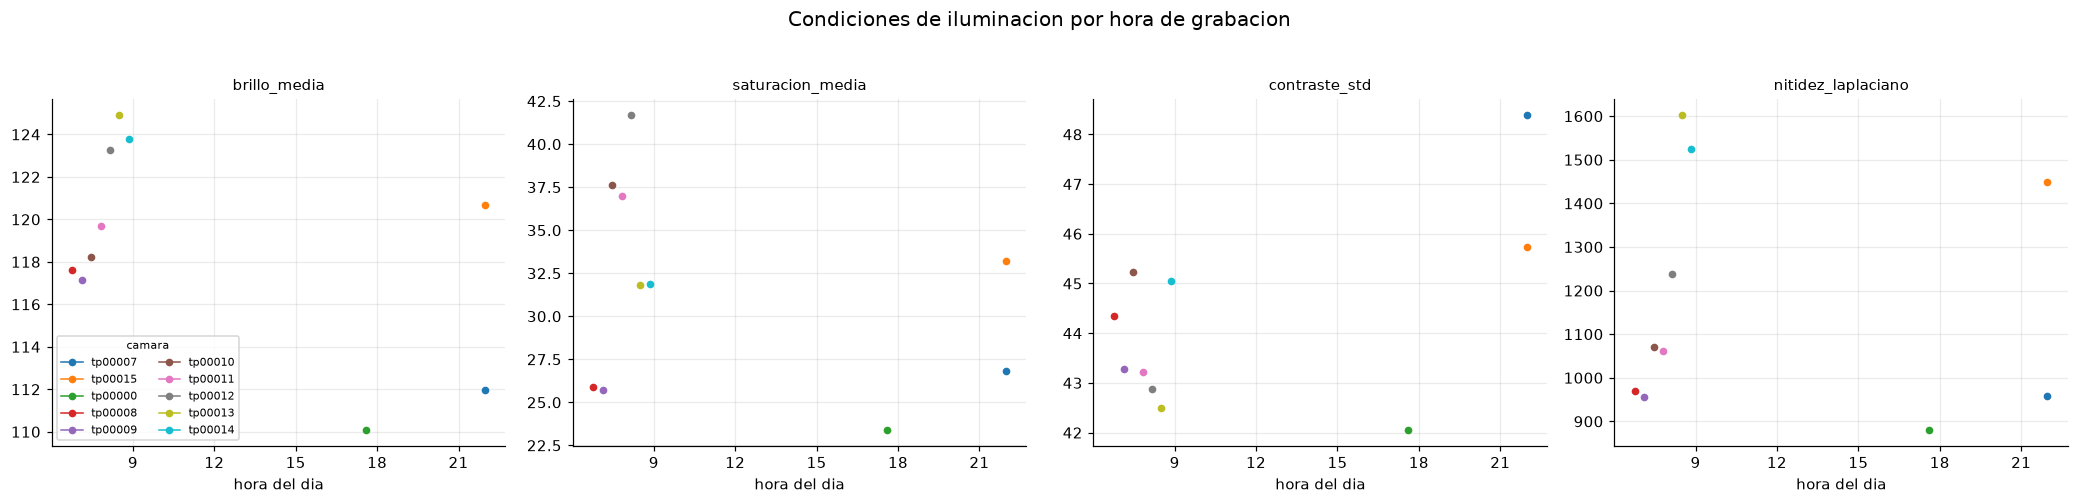

,hora_num,brillo_media,saturacion_media,contraste_std,nitidez_laplaciano,ruido,colorfulness
hora_num,1.000,-0.016,-0.011,0.285,0.221,0.258,-0.226
brillo_media,-0.016,1.000,0.579,-0.230,0.777,0.764,0.562
saturacion_media,-0.011,0.579,1.000,0.060,0.583,0.612,0.916
contraste_std,0.285,-0.230,0.060,1.000,0.149,0.151,-0.085
nitidez_laplaciano,0.221,0.777,0.583,0.149,1.000,0.993,0.515
ruido,0.258,0.764,0.612,0.151,0.993,1.000,0.535
colorfulness,-0.226,0.562,0.916,-0.085,0.515,0.535,1.000


In [42]:
if df_f["hora_num"].nunique() > 1:
    fig, axes = plt.subplots(1, 4, figsize=(19, 4.4))
    for ax, var in zip(axes, ["brillo_media", "saturacion_media", "contraste_std",
                              "nitidez_laplaciano"]):
        for v, g in df_f.groupby("video"):
            serie = g.groupby("hora_num")[var].median()
            ax.plot(serie.index, serie.values, "o-", ms=4, lw=1,
                    label=Path(v).stem.split("_")[-1])
        ax.set_xlabel("hora del dia")
        ax.set_title(var, fontsize=10)
        ax.xaxis.set_major_locator(MaxNLocator(6))
    axes[0].legend(fontsize=7, ncol=2, title="camara", title_fontsize=7)
    fig.suptitle("Condiciones de iluminacion por hora de grabacion", fontsize=13, y=1.03)
    fig.tight_layout()
    fig.savefig(DIR_OUT / "fig11_iluminacion_hora.png", bbox_inches="tight")
    plt.show()

matriz_hora = df_f[["hora_num", "brillo_media", "saturacion_media", "contraste_std",
                    "nitidez_laplaciano", "ruido", "colorfulness"]].corr(method="spearman")
matriz_hora.round(3)

## 16. Exportacion de resultados

Todo queda en `artifacts/eda_videos/` para que el notebook de particionamiento
(`11_procesarimagenes.ipynb`) y el de etiquetado consuman la misma informacion y no tengan que
volver a abrir los videos.

In [43]:
inventario.to_csv(DIR_OUT / "eda_inventario.csv", index=False)
meta.to_csv(DIR_OUT / "eda_metadatos.csv", index=False)
df_f.to_csv(DIR_OUT / "eda_fotogramas.csv", index=False)
df_t.to_csv(DIR_OUT / "eda_transiciones.csv", index=False)
if len(df_d):
    df_d.to_csv(DIR_OUT / "eda_denso.csv", index=False)
resumen_video.to_csv(DIR_OUT / "eda_resumen_por_video.csv", index=False)
matriz.to_csv(DIR_OUT / "eda_correlaciones.csv")
with open(DIR_OUT / "eda_config.json", "w", encoding="utf-8") as fh:
    json.dump({"pesos_calidad": PESOS_CALIDAD,
               "umbrales": {"negro": UMBRAL_NEGRO_BRILLO,
                            "congelado": UMBRAL_CONGELADO_DIFF,
                            "oscuros_pct": UMBRAL_ESCUROS_PCT,
                            "quemados_pct": UMBRAL_QUEMADOS_PCT,
                            "claros_pct": UMBRAL_CLAROS_PCT,
                            "corte_escena": UMBRAL_CORTE_ESCENA,
                            "duplicado_hamming": UMBRAL_DUPLICADO_HAMMING,
                            "racha_stall": UMBRAL_RACHA_STALL,
                            "borroso_relativo": UMBRAL_BORROSO_REL,
                            "brillo_relativo": UMBRAL_BRILLO_REL,
                            "contraste_relativo": UMBRAL_CONTRASTE_REL},
               "muestreo_segundos": MUESTREO_SEGUNDOS}, fh, indent=2)

print("Archivos generados en artifacts/eda_videos/:")
for p in sorted(DIR_OUT.iterdir()):
    print(f"  {p.name:34s} {p.stat().st_size / 1024:>10,.1f} KB")

Archivos generados en artifacts/eda_videos/:
  eda_config.json                           0.5 KB
  eda_correlaciones.csv                     7.1 KB
  eda_denso.csv                         1,218.6 KB
  eda_fotogramas.csv                    2,369.8 KB
  eda_inventario.csv                        1.6 KB
  eda_metadatos.csv                         2.3 KB
  eda_resumen_por_video.csv                 7.3 KB
  eda_transiciones.csv                  1,156.9 KB
  fig01_metadatos.png                      56.6 KB
  fig02_brillo_y_exposicion.png            66.0 KB
  fig02_color.png                          55.9 KB
  fig02_contraste_y_nitidez.png            73.6 KB
  fig02_ruido_y_compresion.png             60.4 KB
  fig03_distribuciones_globales.png       224.7 KB
  fig04_series_temporales.png           1,356.4 KB
  fig05_movimiento.png                    771.0 KB
  fig06_cortes_y_similitud.png             90.0 KB
  fig07_continuidad.png                   101.2 KB
  fig08_cortes_escena.png            

## 17. Resumen ejecutivo

Celda de sintesis: responde con numeros las tres preguntas del inicio.

In [44]:
def construir_hallazgos(resumen, df_f, df_t, df_d):
    '''Redacta los hallazgos del EDA usando los datos calculados.'''
    h = []
    r = resumen

    n_cams, n_fechas = r["camara"].nunique(), r["fecha"].nunique()
    h.append(
        f"INVENTARIO - {len(r)} videos, {inventario['tamano_mb'].sum():,.0f} MB "
        f"({inventario['tamano_mb'].sum() / 1024:,.1f} GB) en formato "
        f"{'/'.join(inventario['formato'].unique())}, con una duracion total de "
        f"{r['duracion_min'].sum() / 60:,.1f} horas, repartidos en {n_cams} "
        f"{'camara' if n_cams == 1 else 'camaras'} y {n_fechas} "
        f"{'fecha de grabacion' if n_fechas == 1 else 'fechas de grabacion'}.")

    h.append(
        f"FORMATO - {meta['ancho'].mode().iat[0]}x{meta['alto'].mode().iat[0]} px "
        f"({meta['megapixeles'].mode().iat[0]} MP, {meta['aspecto_txt'].mode().iat[0]}, "
        f"orientacion {meta['orientacion'].mode().iat[0]}) a "
        f"{meta['fps'].min():.2f}-{meta['fps'].max():.2f} fps en {meta['codec'].nunique()} "
        f"codec(s) ({', '.join(meta['codec'].unique())}). Duraciones entre "
        f"{meta['duracion_min'].min():.1f} y {meta['duracion_min'].max():.1f} minutos. "
        f"El dataset es homogeneo en formato: no hace falta normalizar resolucion.")

    b = r["brillo_p50"]
    h.append(
        f"ILUMINACION - brillo mediano entre {b.min():.1f} y {b.max():.1f} niveles "
        f"(dispersión de {b.max() - b.min():.1f} entre videos); "
        f"{r['pct_subexpuestos'].mean():.2f}% de los fotogramas son subexpuestos y "
        f"{r['pct_sobreexpuestos'].mean():.2f}% sobreexpuestos. La exposición esta bien "
        f"controlada en todo el dataset. Ojo con `pct_quemados`: hay ~"
        f"{df_f['pct_quemados'].median():.1f}% de pixeles en 255 en todos los videos, "
        f"pero eso es ringing del codificador h264 en los bordes claros, no sobreexposicion "
        f"real; por eso los umbrales de recorte son altos. Para encontrar anomalias reales "
        f"hay que usar los flags relativos: {r['pct_brillo_anomalos'].mean():.1f}% de "
        f"fotogramas tienen un brillo que se desvía más de {UMBRAL_BRILLO_REL:.0%} de la "
        f"mediana de su video y {r['pct_contraste_bajo'].mean():.1f}% tienen contraste bajo.")

    h.append(
        f"CONTRASTE Y NITIDEZ - contraste mediano {r['contraste_p50'].min():.1f} a "
        f"{r['contraste_p50'].max():.1f} niveles, rango dinamico mediano "
        f"{r['rango_din_p50'].median():.1f} y entropia "
        f"{r['entropia_p50'].min():.2f} a {r['entropia_p50'].max():.2f} bits. "
        f"{r['pct_borrosos'].mean():.1f}% de los fotogramas esta por debajo del "
        f"{UMBRAL_BORROSO_REL:.0%} de la nitidez de su propio video; el video con mas "
        f"fotogramas borrosos es {r.loc[r['pct_borrosos'].idxmax(), 'video']} "
        f"({r['pct_borrosos'].max():.1f}%).")

    h.append(
        f"COMPRESION - bitrate {meta['kbps'].min():,.0f} a {meta['kbps'].max():,.0f} kbps "
        f"({meta['bits_por_pixel'].min():.2f} a {meta['bits_por_pixel'].max():.2f} bits/pixel), "
        f"ruido mediano {r['ruido_p50'].min():.2f} a {r['ruido_p50'].max():.2f} y blockiness "
        f"{r['blockiness_p50'].min():.2f} a {r['blockiness_p50'].max():.2f}. "
        f"La compresion es homogenea; el ruido tambien.")

    h.append(
        f"COLOR - colorfulness {r['colorfulness_p50'].min():.1f} a "
        f"{r['colorfulness_p50'].max():.1f}, saturacion {r['saturacion_p50'].min():.1f} a "
        f"{r['saturacion_p50'].max():.1f} y tono dominante entre {r['tono_p50'].min():.0f} y "
        f"{r['tono_p50'].max():.0f} grados. Balance de blancos de "
        f"{r['balance_blancos_p50'].min():+.1f} a {r['balance_blancos_p50'].max():+.1f} "
        f"(positivo = luz calida). Los cambios de tono entre videos reflejan las distintas "
        f"condiciones de iluminacion de la granja.")

    if len(df_t):
        h.append(
            f"MOVIMIENTO - en promedio cambia el {r['pct_cambiados_p50'].median():.2f}% de los "
            f"pixeles entre muestras, con magnitud de flujo de "
            f"{r['flujo_por_seg_p50'].median():.2f} px/s. La coherencia del flujo es "
            f"{r['coherencia_p50'].min():.2f} a {r['coherencia_p50'].max():.2f}: "
            f"{'el movimiento es sobre todo local (las gallinas)' if r['coherencia_p50'].median() < 0.5 else 'hay movimiento global de camara importante'}, "
            f"lo que confirma que la camara esta fija. Sacudida mediana "
            f"{r['sacudida_px_p50'].median():.2f} px/muestra y rotacion maxima "
            f"{r['rotacion_max'].max():.3f} grados.")

        h.append(
            f"CONTINUIDAD Y ESCENAS - con el umbral fijo ({UMBRAL_CORTE_ESCENA}) se detectan "
            f"{int(r['cortes_escena'].sum())} cambios de escena y con el criterio adaptativo "
            f"{int(r['cortes_adaptativos'].sum())} (maximo "
            f"{int(r['cortes_adaptativos'].max())} en un video). La similitud mediana entre "
            f"muestras va de {r['hist_correl_p50'].min():.3f} a {r['hist_correl_p50'].max():.3f}: "
            f"las grabaciones son visualmente estables, asi que los cortes no son de edicion "
            f"sino cambios de luz dentro de videos largos.")

    if len(df_d):
        h.append(
            f"BARRIDO DENSO - sobre {len(df_d):,} pares de fotogramas consecutivos a FPS nativo: "
            f"{int(df_d['negro'].sum())} fotogramas negros, "
            f"{100 * df_d['congelado'].mean():.2f}% de transiciones congeladas y "
            f"{100 * df_d['identico'].mean():.1f}% de fotogramas idénticos al anterior "
            f"(normal en una escena estática a 15 fps). Lo relevante es la racha: el máximo "
            f"es de {int(df_d['racha_identicos'].max())} fotogramas y hay "
            f"{int(df_d['es_stall'].sum())} stalls (rachas >= {UMBRAL_RACHA_STALL}). "
            f"La grabación es continua, no pierde fotogramas y no se detiene.")

    h.append(
        f"REDUNDANCIA - de {len(df_f):,} fotogramas muestreados solo {n_unicos:,} son imagenes "
        f"distintas, es decir una redundancia del "
        f"{100 * (1 - n_unicos / len(df_f)):.1f}%. El muestreo cada {MUESTREO_SEGUNDOS:.0f} s "
        f"es conservador: se puede aumentar el intervalo sin perder cobertura.")

    q = r["calidad_p50"]
    h.append(
        f"CALIDAD GLOBAL - score mediano entre {q.min():.1f} y {q.max():.1f} sobre 100. "
        f"Mejor video: {r.loc[q.idxmax(), 'video']} ({q.max():.1f}). "
        f"Peor video: {r.loc[q.idxmin(), 'video']} ({q.min():.1f}). "
        f"El score combina nitidez ({PESOS_CALIDAD['nitidez']:.0%}), exposicion "
        f"({PESOS_CALIDAD['exposicion']:.0%}), contraste ({PESOS_CALIDAD['contraste']:.0%}), "
        f"color ({PESOS_CALIDAD['color']:.0%}) y estabilidad "
        f"({PESOS_CALIDAD['estabilidad']:.0%}).")
    return h


hallazgos = construir_hallazgos(resumen_video, df_f, df_t, df_d)
for i, texto in enumerate(hallazgos, 1):
    print(f"{i:2d}. {texto}\n")

 1. INVENTARIO - 10 videos, 2,560 MB (2.5 GB) en formato mp4, con una duracion total de 3.4 horas, repartidos en 10 camaras y 3 fechas de grabacion.

 2. FORMATO - 1920x1080 px (2.07 MP, 16:9, orientacion horizontal) a 15.00-15.00 fps en 1 codec(s) (h264). Duraciones entre 14.3 y 20.9 minutos. El dataset es homogeneo en formato: no hace falta normalizar resolucion.

 3. ILUMINACION - brillo mediano entre 110.1 y 124.9 niveles (dispersión de 14.8 entre videos); 0.00% de los fotogramas son subexpuestos y 0.08% sobreexpuestos. La exposición esta bien controlada en todo el dataset. Ojo con `pct_quemados`: hay ~2.0% de pixeles en 255 en todos los videos, pero eso es ringing del codificador h264 en los bordes claros, no sobreexposicion real; por eso los umbrales de recorte son altos. Para encontrar anomalias reales hay que usar los flags relativos: 0.0% de fotogramas tienen un brillo que se desvía más de 15% de la mediana de su video y 0.1% tienen contraste bajo.

 4. CONTRASTE Y NITIDEZ - c